# Data Analysis

In [3]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
data_train = pd.read_csv('data/X_train.csv')
data_train.head()

,ROW_ID,TS,ALLOCATION,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,...,SIGNED_VOLUME_8,SIGNED_VOLUME_7,SIGNED_VOLUME_6,SIGNED_VOLUME_5,SIGNED_VOLUME_4,SIGNED_VOLUME_3,SIGNED_VOLUME_2,SIGNED_VOLUME_1,MEDIAN_DAILY_TURNOVER,GROUP
0,0,DATE_0001,ALLOCATION_01,-0.018192,-0.000306,-0.006881,-0.002393,0.000507,-0.001270,-0.002539,...,0.818730,0.941014,0.714129,-0.323847,0.525097,0.363601,-0.219328,NaN,0.096905,1
1,1,DATE_0001,ALLOCATION_02,-0.006394,-0.001059,0.001565,0.000033,0.002829,0.001725,0.000875,...,-1.390336,-0.651784,-0.896826,-0.636931,-1.074450,-0.748884,-0.718912,NaN,0.009974,4
2,2,DATE_0001,ALLOCATION_03,-0.016587,-0.004517,-0.005306,0.004314,0.006471,-0.005868,-0.005030,...,0.961318,0.452482,1.588321,0.790039,1.394445,0.493521,0.268094,NaN,0.044186,1
3,3,DATE_0001,ALLOCATION_04,-0.005344,0.002790,0.006937,-0.004246,-0.005051,-0.000330,-0.000117,...,-0.483377,-0.565114,-0.631710,-0.663300,-1.615905,-0.959046,-0.478789,NaN,0.001150,2
4,4,DATE_0001,ALLOCATION_05,-0.010506,-0.005491,0.007752,-0.012299,0.002191,0.003282,0.000495,...,0.268005,0.757707,1.524626,1.565541,1.563963,1.063209,0.921333,NaN,NaN,4


In [5]:
# Check for missing values
missing_values = data_train.isnull().sum()
print("Missing Values per Column:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found")
print(f"\nTotal missing values: {missing_values.sum()}")
print(f"Percentage of missing data: {(missing_values.sum() / (data_train.shape[0] * data_train.shape[1]) * 100):.2f}%")

Missing Values per Column:
RET_20                       58
RET_19                       50
RET_18                       42
RET_17                       34
RET_16                       26
RET_15                       18
RET_14                       13
RET_13                        9
RET_12                        6
RET_11                        4
RET_10                        2
SIGNED_VOLUME_20           8498
SIGNED_VOLUME_19           3002
SIGNED_VOLUME_18            859
SIGNED_VOLUME_17             58
SIGNED_VOLUME_16             50
SIGNED_VOLUME_15             42
SIGNED_VOLUME_14             34
SIGNED_VOLUME_13             26
SIGNED_VOLUME_12             18
SIGNED_VOLUME_11             13
SIGNED_VOLUME_10              9
SIGNED_VOLUME_9               6
SIGNED_VOLUME_8               4
SIGNED_VOLUME_7               2
SIGNED_VOLUME_1          387506
MEDIAN_DAILY_TURNOVER      3638
dtype: int64

Total missing values: 404027
Percentage of missing data: 1.70%


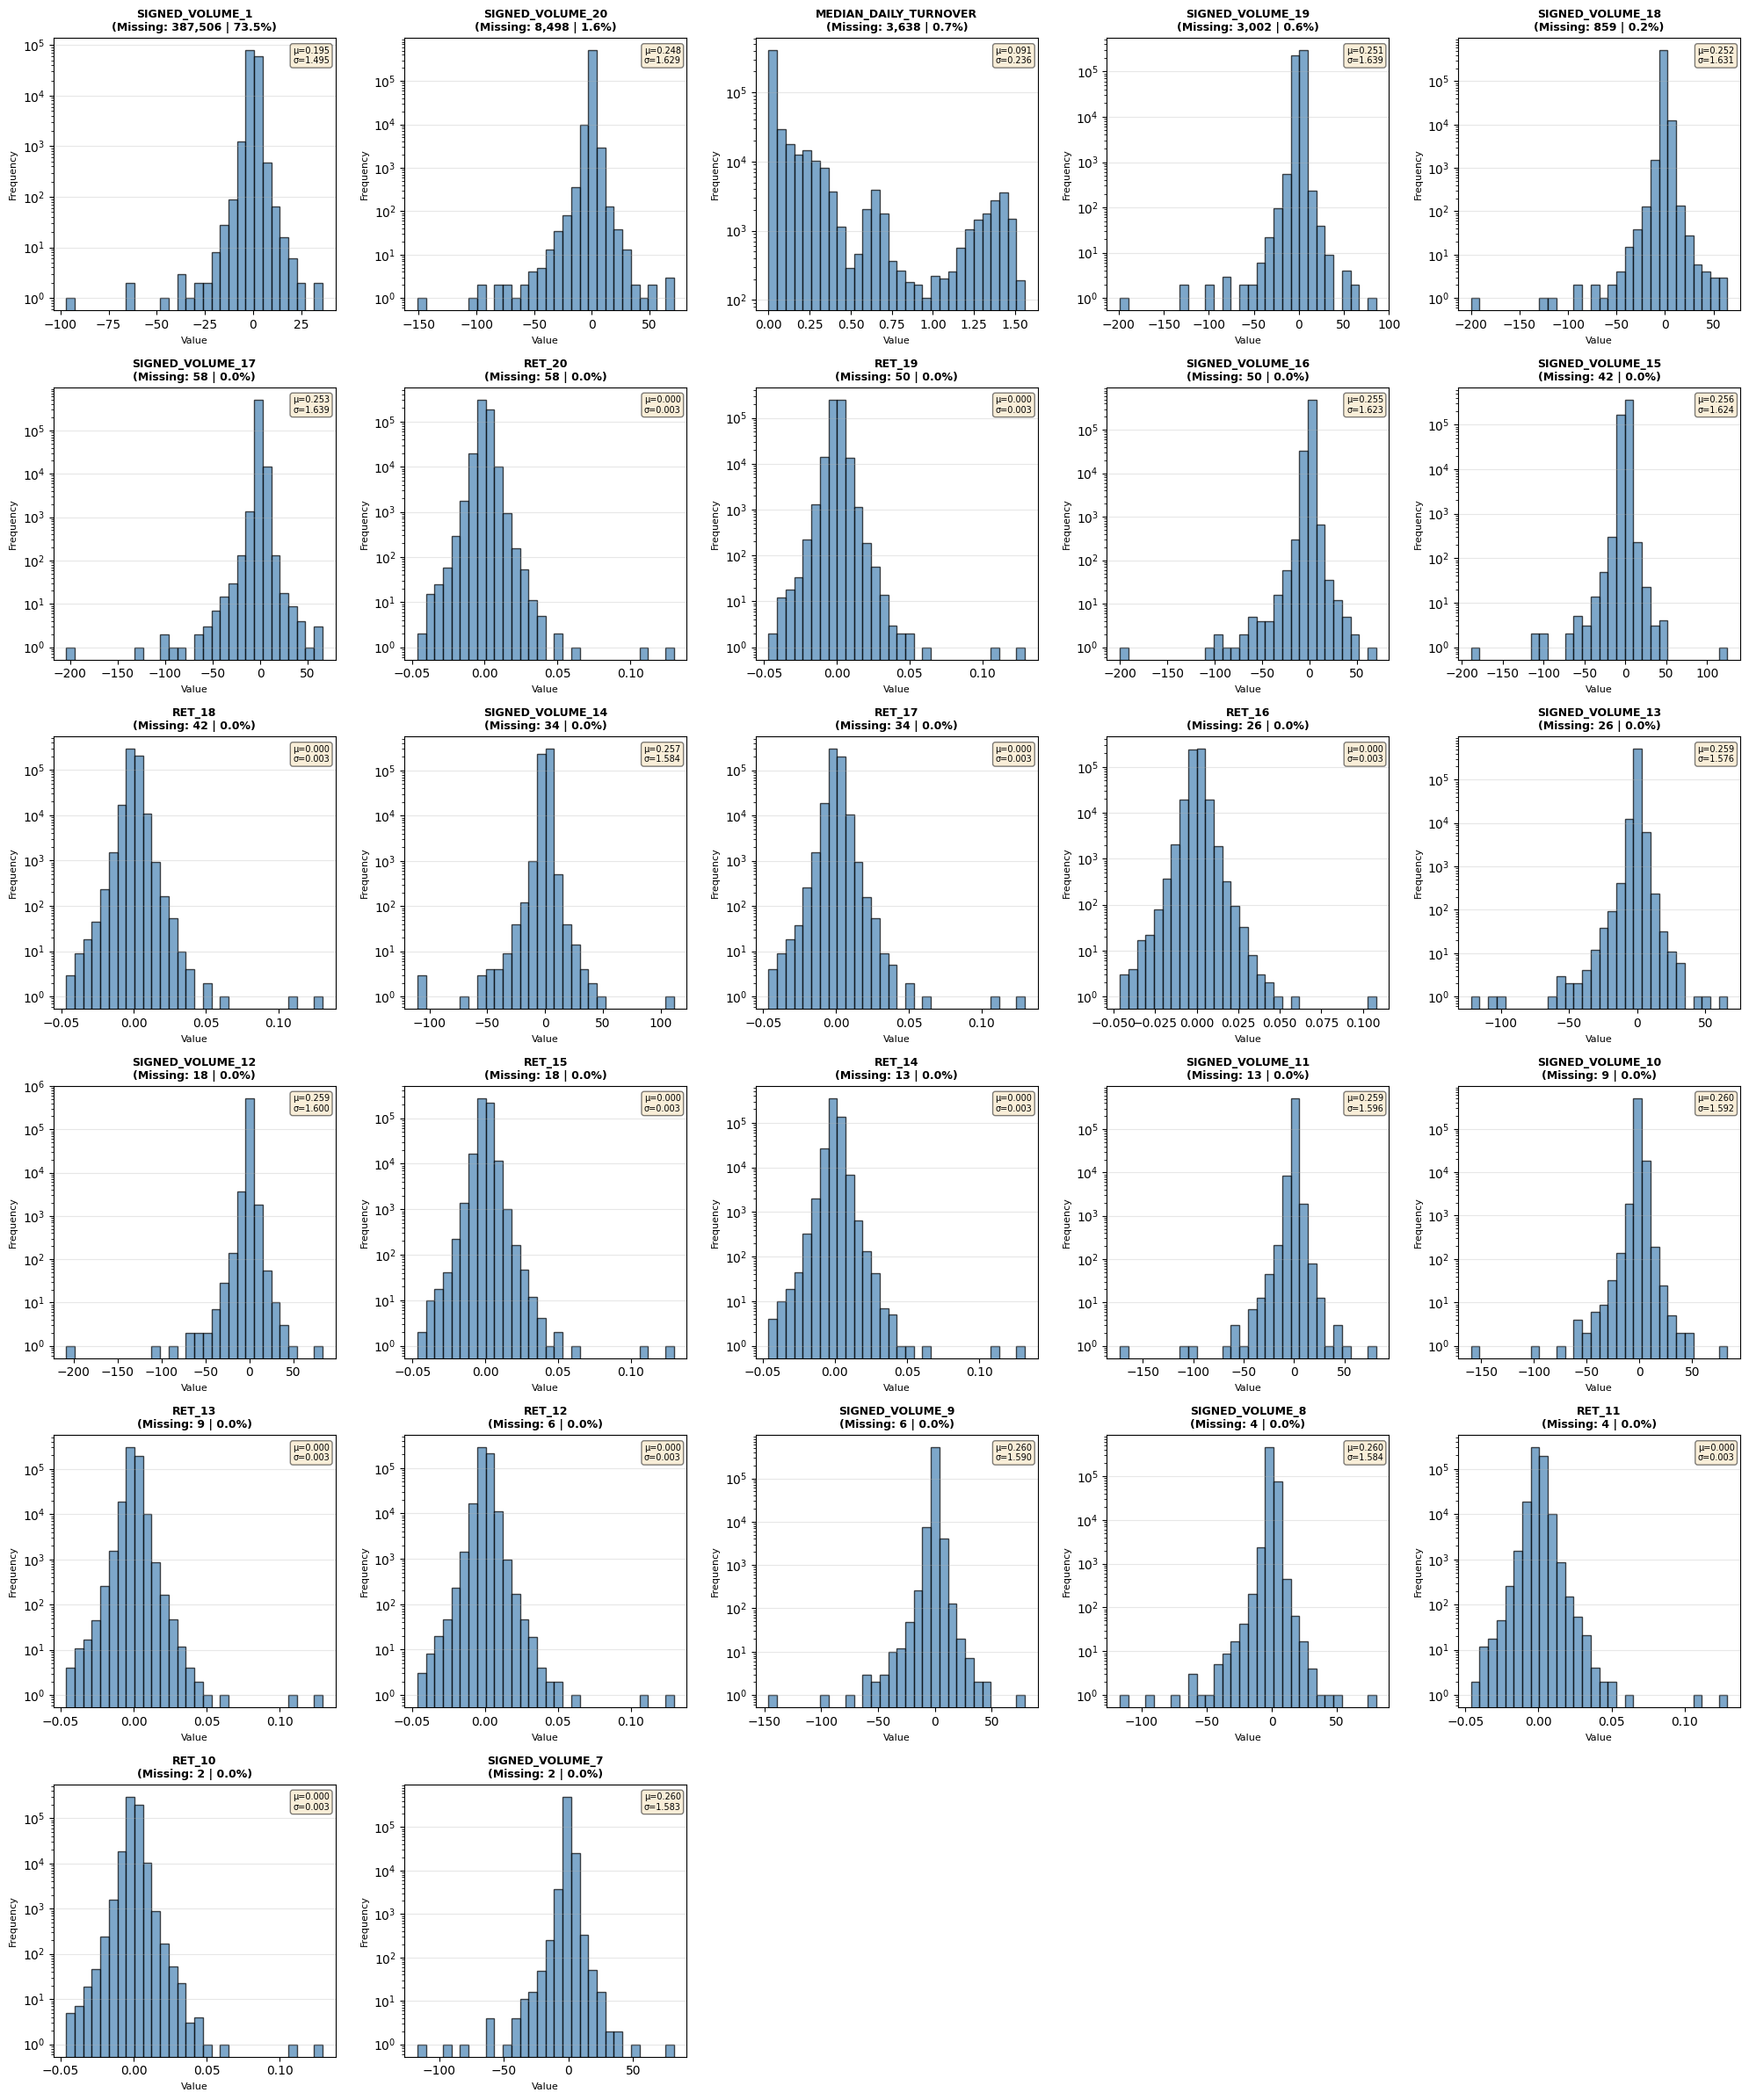


Total columns with missing data: 27


In [6]:
# Create histograms for columns with missing values to visualize data distribution
# Filter columns with missing values
missing_cols = missing_values[missing_values > 0].sort_values(ascending=False)

if len(missing_cols) > 0:
    # Calculate number of rows needed (5 graphs per row)
    n_cols_to_plot = len(missing_cols)
    n_plots_per_row = 5
    n_rows = (n_cols_to_plot + n_plots_per_row - 1) // n_plots_per_row
    
    # Create figure with subplots
    fig, axes = plt.subplots(n_rows, n_plots_per_row, figsize=(20, 4 * n_rows))
    
    # Flatten axes array if needed
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    else:
        axes = axes.flatten()
    
    # Create a histogram for each column with missing values
    for idx, col in enumerate(missing_cols.index):
        ax = axes[idx]
        
        # Get data for this column (excluding NaN)
        data_col = data_train[col].dropna()
        
        # Create histogram
        ax.hist(data_col, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
        
        # Calculate statistics
        count_missing = missing_cols[col]
        count_present = len(data_col)
        pct_missing = (count_missing / len(data_train)) * 100
        
        # Add title with statistics
        ax.set_title(f'{col}\n(Missing: {count_missing:,} | {pct_missing:.1f}%)', 
                    fontsize=9, fontweight='bold')
        ax.set_xlabel('Value', fontsize=8)
        ax.set_ylabel('Frequency', fontsize=8)
        ax.grid(axis='y', alpha=0.3)
        
        # Use logarithmic scale for better readability
        ax.set_yscale('log')
        
        # Add statistics text
        stats_text = f'μ={data_col.mean():.3f}\nσ={data_col.std():.3f}'
        ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, 
               fontsize=7, verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Hide unused subplots
    for idx in range(n_cols_to_plot, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nTotal columns with missing data: {n_cols_to_plot}")
else:
    print("No missing values found in the dataset.")

# NaN Analysis on Engineered Features

In [7]:
# Check for NaN in engineered features
RET_features = [f"RET_{i}" for i in range(1, 21)]

# Create engineered features (same as in ridge_regression.py)
for i in [3, 5, 10, 15, 20]:
    data_train[f"AVERAGE_PERF_{i}"] = data_train[RET_features[:i]].mean(1)
    data_train[f"STD_PERF_{i}"] = data_train[RET_features[:i]].std(1)
    
    # Market-wide average performance and volatility on same day
    data_train[f"ALLOCATIONS_AVERAGE_PERF_{i}"] = data_train.groupby("TS")[
        f"AVERAGE_PERF_{i}"
    ].transform("mean")
    data_train[f"ALLOCATIONS_STD_PERF_{i}"] = data_train.groupby("TS")[
        f"STD_PERF_{i}"
    ].transform("mean")

# Check NaN in engineered features
engineered_features = (
    [f"AVERAGE_PERF_{i}" for i in [3, 5, 10, 15, 20]]
    + [f"ALLOCATIONS_AVERAGE_PERF_{i}" for i in [3, 5, 10, 15, 20]]
    + [f"STD_PERF_{i}" for i in [20]]
    + [f"ALLOCATIONS_STD_PERF_{i}" for i in [20]]
)
nan_in_engineered = data_train[engineered_features].isnull().sum()

print("NaN count in engineered features:")
print(nan_in_engineered[nan_in_engineered > 0])
print(f"\nTotal NaN in engineered features: {nan_in_engineered.sum()}")

# Check which rows have NaN in original features
rows_with_nan = data_train[RET_features].isnull().any(axis=1).sum()
print(f"\nRows with at least one NaN in RET features: {rows_with_nan}")
print(f"Percentage: {(rows_with_nan / len(data_train)) * 100:.2f}%")

C:\Users\vicca\AppData\Local\Temp\ipykernel_12664\1559570916.py:6: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  data_train[f"AVERAGE_PERF_{i}"] = data_train[RET_features[:i]].mean(1)
C:\Users\vicca\AppData\Local\Temp\ipykernel_12664\1559570916.py:7: Pandas4Warning: Starting with pandas version 4.0 all arguments of std will be keyword-only.
  data_train[f"STD_PERF_{i}"] = data_train[RET_features[:i]].std(1)
C:\Users\vicca\AppData\Local\Temp\ipykernel_12664\1559570916.py:6: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  data_train[f"AVERAGE_PERF_{i}"] = data_train[RET_features[:i]].mean(1)
C:\Users\vicca\AppData\Local\Temp\ipykernel_12664\1559570916.py:7: Pandas4Warning: Starting with pandas version 4.0 all arguments of std will be keyword-only.
  data_train[f"STD_PERF_{i}"] = data_train[RET_features[:i]].std(1)
C:\Users\vicca\AppData\Local\Temp\ipykernel_12664\1559570916.py:6: Pandas4Warnin

NaN count in engineered features:
Series([], dtype: int64)

Total NaN in engineered features: 0

Rows with at least one NaN in RET features: 58
Percentage: 0.01%


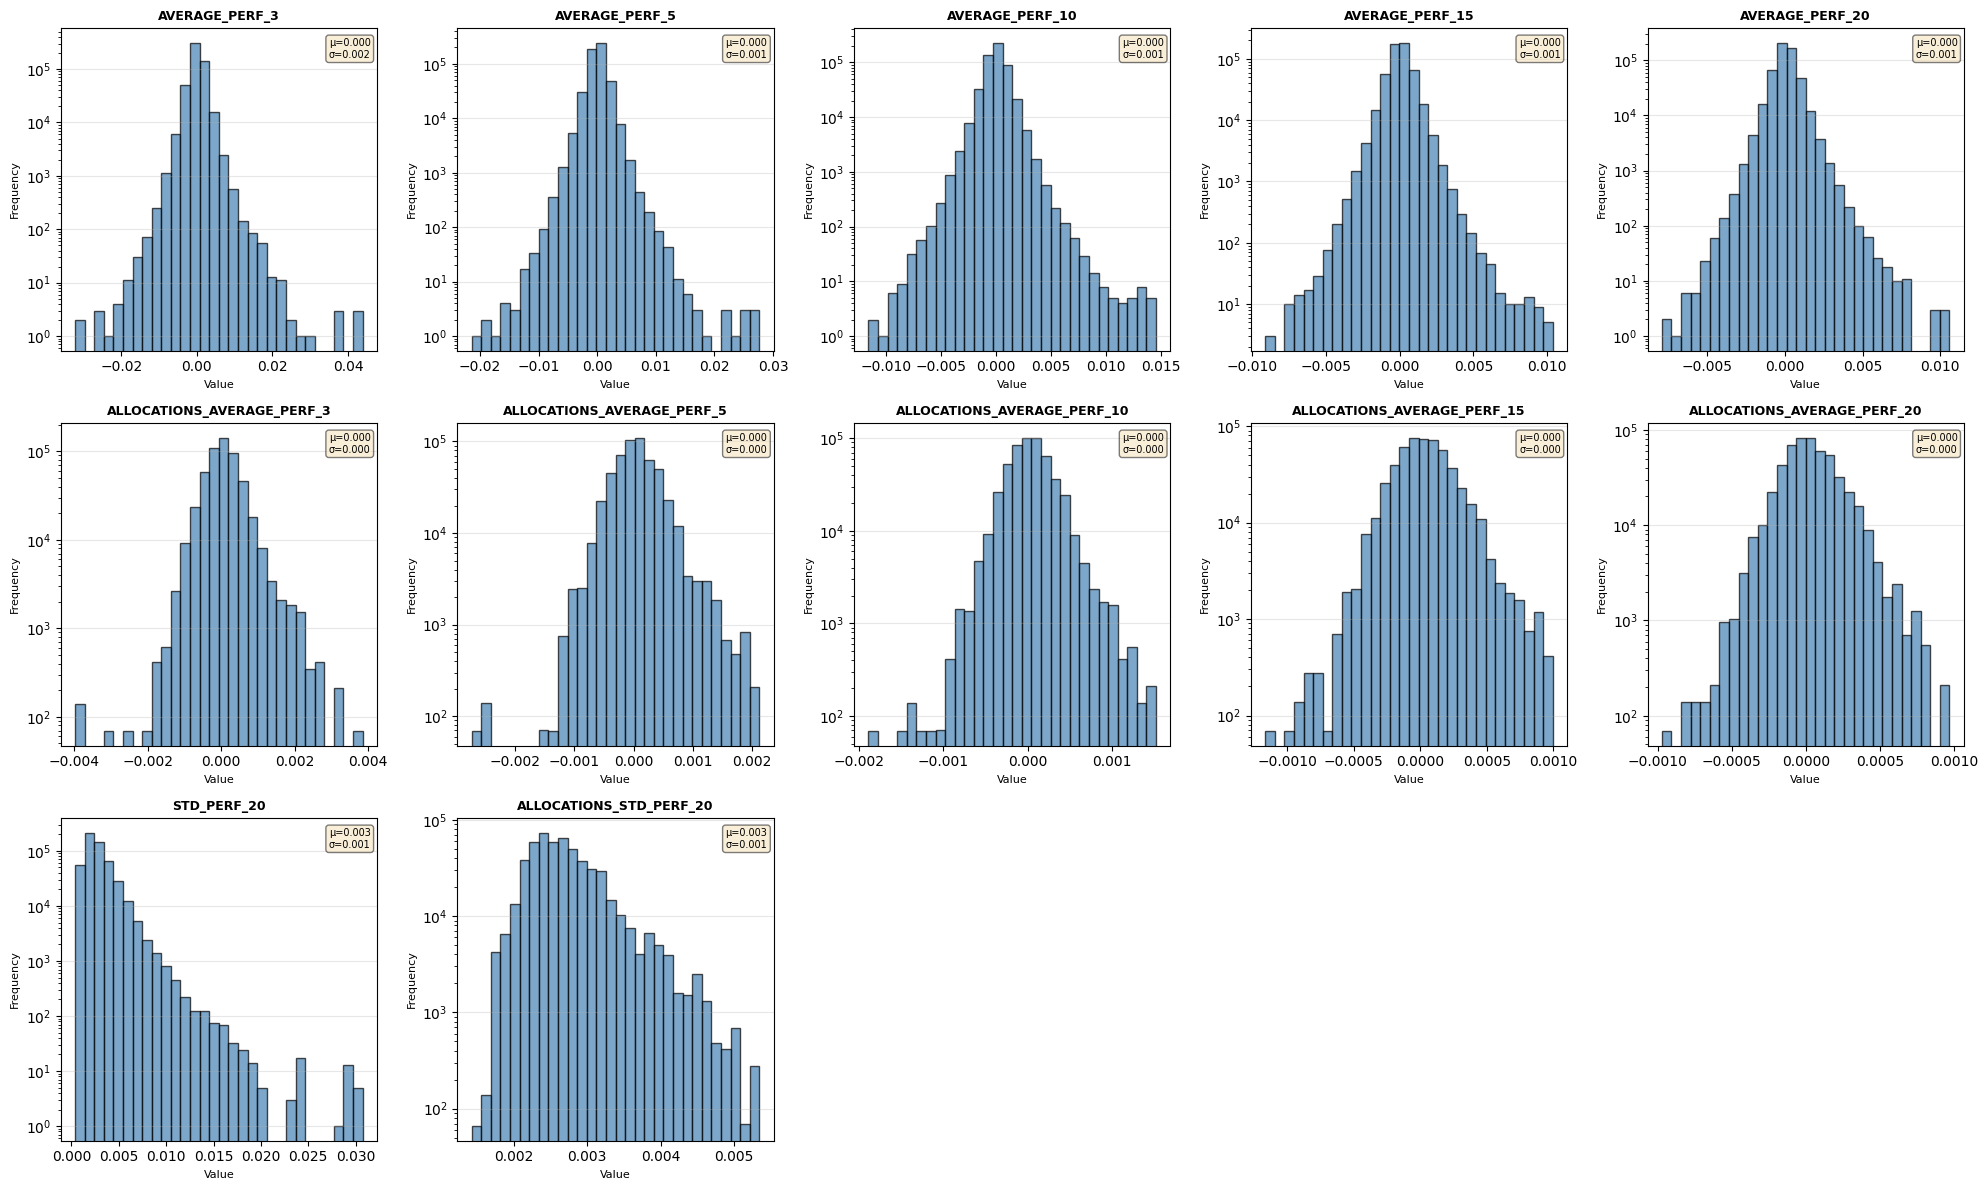

Engineered features visualization: 12 features displayed


In [8]:
# Visualize distributions of engineered features
# Calculate number of rows needed (5 graphs per row)
n_cols_to_plot = len(engineered_features)
n_plots_per_row = 5
n_rows = (n_cols_to_plot + n_plots_per_row - 1) // n_plots_per_row

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_plots_per_row, figsize=(20, 4 * n_rows))

# Flatten axes array if needed
if n_rows == 1:
    axes = axes.reshape(1, -1)
else:
    axes = axes.flatten()

# Create a histogram for each engineered feature
for idx, col in enumerate(engineered_features):
    ax = axes[idx]
    
    # Get data for this column (excluding NaN - should be none as confirmed)
    data_col = data_train[col].dropna()
    
    # Create histogram
    ax.hist(data_col, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    
    # Add title
    ax.set_title(f'{col}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Value', fontsize=8)
    ax.set_ylabel('Frequency', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    
    # Use logarithmic scale for better readability
    ax.set_yscale('log')
    
    # Add statistics text
    stats_text = f'μ={data_col.mean():.3f}\nσ={data_col.std():.3f}'
    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, 
           fontsize=7, verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide unused subplots
for idx in range(n_cols_to_plot, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print(f"Engineered features visualization: {n_cols_to_plot} features displayed")

coherent to use the median for almost all the data, except the standards deviations, we can use the peak of the curve for them, using the principal mode of the distribution (Kernel density estimation)

Maybe as an alternative to this, we can use for all data MICE (Multiple Imputation by chained equations)

## EDA - Statistiques Descriptives et Corrélations

In [15]:
import seaborn as sns
from scipy import stats

# Use data_train from previous cell and prepare X_train
X_train = data_train.drop(columns=['ROW_ID', 'TS', 'ALLOCATION', 'GROUP'])

print(f"Données chargées: {X_train.shape[0]} lignes, {X_train.shape[1]} colonnes")
print(f"Target shape: {y_train.shape}")

Données chargées: 527073 lignes, 61 colonnes
Target shape: (527073, 1)


In [16]:
# Statistiques descriptives complètes
print("=" * 80)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 80)

stats_df = pd.DataFrame({
    'Mean': X_train.mean(),
    'Std': X_train.std(),
    'Min': X_train.min(),
    'Max': X_train.max(),
    'Skewness': X_train.skew(),
    'Kurtosis': X_train.kurtosis(),
    'Missing %': (X_train.isnull().sum() / len(X_train) * 100).round(2)
})

print(stats_df.to_string())
print(f"\nTotal features: {len(X_train.columns)}")


STATISTIQUES DESCRIPTIVES
                                 Mean       Std           Min         Max  Skewness    Kurtosis  Missing %
RET_20                       0.000021  0.003102 -4.622569e-02    0.129840  0.122445   15.658126       0.01
RET_19                       0.000025  0.003089 -4.698683e-02    0.129343  0.181787   15.426985       0.01
RET_18                       0.000027  0.003082 -4.677892e-02    0.130503  0.178572   15.574769       0.01
RET_17                       0.000025  0.003075 -4.636841e-02    0.129712  0.182360   15.499966       0.01
RET_16                       0.000024  0.003065 -4.627304e-02    0.107983  0.041145    9.551736       0.00
RET_15                       0.000027  0.003061 -4.661937e-02    0.129469  0.186005   15.596066       0.00
RET_14                       0.000026  0.003059 -4.587277e-02    0.131424  0.191171   16.116575       0.00
RET_13                       0.000026  0.003056 -4.616847e-02    0.129362  0.179715   15.889576       0.00
RET_12     


ANALYSE SKEWNESS (Asymétrie)

Top 10 features avec Skewness POSITIVE (queue à droite):
MEDIAN_DAILY_TURNOVER      4.322450
STD_PERF_3                 3.099373
STD_PERF_5                 3.002151
STD_PERF_10                2.788871
STD_PERF_15                2.617103
STD_PERF_20                2.504463
ALLOCATIONS_STD_PERF_3     1.637352
ALLOCATIONS_STD_PERF_5     1.466944
ALLOCATIONS_STD_PERF_10    1.381631
ALLOCATIONS_STD_PERF_15    1.276790
dtype: float64

Top 10 features avec Skewness NÉGATIVE (queue à gauche):
SIGNED_VOLUME_10   -3.671384
SIGNED_VOLUME_1    -3.897994
SIGNED_VOLUME_11   -4.712712
SIGNED_VOLUME_20   -4.925758
SIGNED_VOLUME_15   -5.831602
SIGNED_VOLUME_12   -6.410861
SIGNED_VOLUME_18   -6.979930
SIGNED_VOLUME_16   -7.135661
SIGNED_VOLUME_17   -7.423726
SIGNED_VOLUME_19   -7.429370
dtype: float64


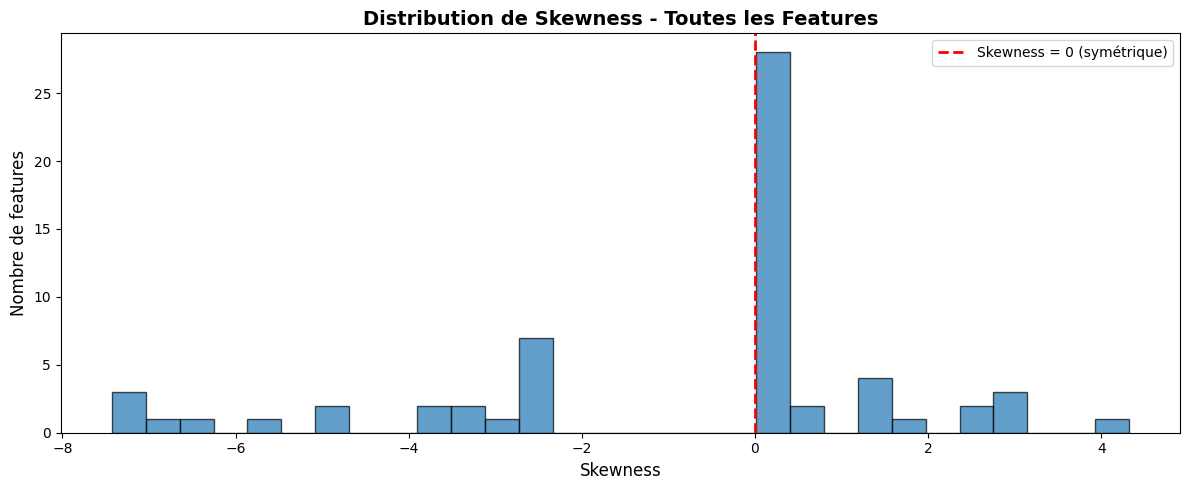


Skewness moyen: -0.8615
Nombre de features avec |Skewness| > 1: 31


In [17]:
# Analyse Skewness
print("\n" + "=" * 80)
print("ANALYSE SKEWNESS (Asymétrie)")
print("=" * 80)

skewness = X_train.skew().sort_values(ascending=False)
print("\nTop 10 features avec Skewness POSITIVE (queue à droite):")
print(skewness.head(10))

print("\nTop 10 features avec Skewness NÉGATIVE (queue à gauche):")
print(skewness.tail(10))

# Visualiser la distribution des skewness
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(skewness, bins=30, edgecolor='black', alpha=0.7)
ax.set_xlabel('Skewness', fontsize=12)
ax.set_ylabel('Nombre de features', fontsize=12)
ax.set_title('Distribution de Skewness - Toutes les Features', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Skewness = 0 (symétrique)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nSkewness moyen: {skewness.mean():.4f}")
print(f"Nombre de features avec |Skewness| > 1: {(skewness.abs() > 1).sum()}")


In [18]:
# Matrice de corrélation - Visualisation complète
print("\n" + "=" * 80)
print("MATRICE DE CORRÉLATION")
print("=" * 80)

# Calculer les corrélations
corr_matrix = X_train.corr()

# Afficher statistiques des corrélations
print(f"\nNombre total de paires de features: {len(X_train.columns) * (len(X_train.columns) - 1) // 2}")

# Corrélations fortes (> 0.7)
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            strong_corr.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if strong_corr:
    strong_corr_df = pd.DataFrame(strong_corr).sort_values('Correlation', ascending=False, key=abs)
    print(f"\nCorrélations fortes (|r| > 0.7): {len(strong_corr_df)}")
    print(strong_corr_df.to_string(index=False))
else:
    print(f"\nAucune corrélation forte (|r| > 0.7) trouvée")

# Corrélations modérées (0.5 - 0.7)
moderate_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if 0.5 <= abs(corr_matrix.iloc[i, j]) <= 0.7:
            moderate_corr.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if moderate_corr:
    print(f"\nCorrélations modérées (0.5 < |r| <= 0.7): {len(moderate_corr)}")
    print(f"(affichage limité aux 10 premières)")
    moderate_corr_df = pd.DataFrame(moderate_corr).sort_values('Correlation', ascending=False, key=abs)
    print(moderate_corr_df.head(10).to_string(index=False))



MATRICE DE CORRÉLATION

Nombre total de paires de features: 1830

Corrélations fortes (|r| > 0.7): 28
                  Feature 1                   Feature 2  Correlation
    ALLOCATIONS_STD_PERF_15     ALLOCATIONS_STD_PERF_20     0.974808
                STD_PERF_15                 STD_PERF_20     0.965584
    ALLOCATIONS_STD_PERF_10     ALLOCATIONS_STD_PERF_15     0.959939
                STD_PERF_10                 STD_PERF_15     0.939721
    ALLOCATIONS_STD_PERF_10     ALLOCATIONS_STD_PERF_20     0.922472
     ALLOCATIONS_STD_PERF_5     ALLOCATIONS_STD_PERF_10     0.912401
     ALLOCATIONS_STD_PERF_3      ALLOCATIONS_STD_PERF_5     0.903942
                STD_PERF_10                 STD_PERF_20     0.901072
            AVERAGE_PERF_15             AVERAGE_PERF_20     0.871835
ALLOCATIONS_AVERAGE_PERF_15 ALLOCATIONS_AVERAGE_PERF_20     0.863713
     ALLOCATIONS_STD_PERF_5     ALLOCATIONS_STD_PERF_15     0.860730
                 STD_PERF_5                 STD_PERF_10     0.855936


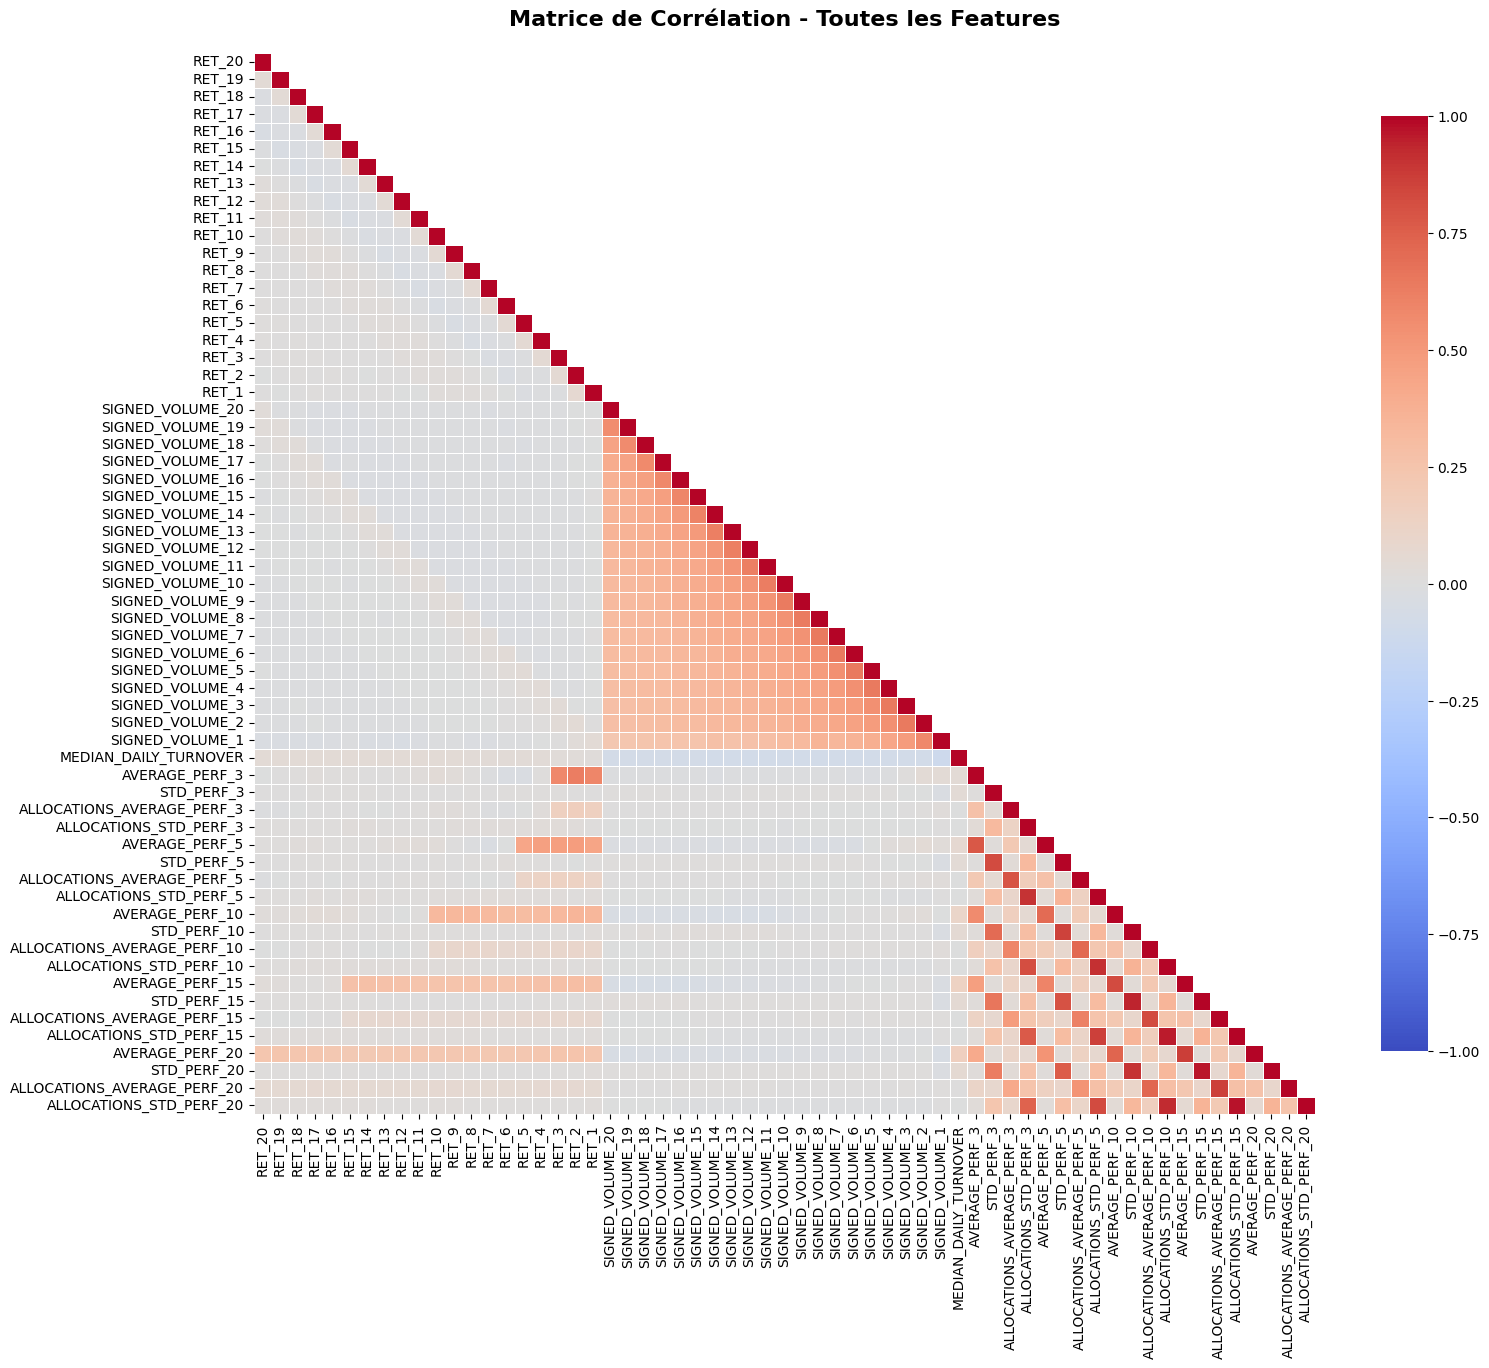

In [19]:
# Heatmap de corrélation (complète)
fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Matrice de Corrélation - Toutes les Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


In [20]:
# Résumé global
print("\n" + "=" * 80)
print("RÉSUMÉ GLOBAL")
print("=" * 80)

print(f"\n📊 Dataset:")
print(f"   Nombre de samples: {len(X_train):,}")
print(f"   Nombre de features: {len(X_train.columns)}")
print(f"   Nombre total de valeurs: {X_train.size:,}")
print(f"   Valeurs manquantes: {X_train.isnull().sum().sum():,} ({X_train.isnull().sum().sum() / X_train.size * 100:.2f}%)")

print(f"\n📈 Moyenne par feature:")
print(f"   Moyenne globale: {X_train.mean().mean():.6f}")
print(f"   Min: {X_train.mean().min():.6f}")
print(f"   Max: {X_train.mean().max():.6f}")

print(f"\n📐 Skewness:")
print(f"   Moyenne: {X_train.skew().mean():.4f}")
print(f"   Min (plus négative): {X_train.skew().min():.4f}")
print(f"   Max (plus positive): {X_train.skew().max():.4f}")
print(f"   Features presque symétriques (|skew| < 0.5): {(X_train.skew().abs() < 0.5).sum()}")
print(f"   Features modérément asymétriques (0.5 < |skew| < 1): {((X_train.skew().abs() >= 0.5) & (X_train.skew().abs() < 1)).sum()}")
print(f"   Features fortement asymétriques (|skew| >= 1): {(X_train.skew().abs() >= 1).sum()}")

print(f"\n🔗 Corrélations:")
print(f"   Corrélation moyenne (en valeur absolue): {corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)].mean():.4f}")
print(f"   Max corrélation (excl. diagonale): {corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)].max():.4f}")



RÉSUMÉ GLOBAL

📊 Dataset:
   Nombre de samples: 527,073
   Nombre de features: 61
   Nombre total de valeurs: 32,151,453
   Valeurs manquantes: 404,027 (1.26%)

📈 Moyenne par feature:
   Moyenne globale: 0.085181
   Min: 0.000021
   Max: 0.260059

📐 Skewness:
   Moyenne: -0.8615
   Min (plus négative): -7.4294
   Max (plus positive): 4.3225
   Features presque symétriques (|skew| < 0.5): 29
   Features modérément asymétriques (0.5 < |skew| < 1): 1
   Features fortement asymétriques (|skew| >= 1): 31

🔗 Corrélations:
   Corrélation moyenne (en valeur absolue): 0.0805
   Max corrélation (excl. diagonale): 0.9748


## Target Analysis - Analyse de la Variable à Prédire

In [21]:
# Target Analysis - Statistical Summary
print("=" * 80)
print("TARGET ANALYSIS - STATISTICAL SUMMARY")
print("=" * 80)

# Flatten y_train if it's a DataFrame
y_train_values = y_train.values.ravel()

# Descriptive statistics
print(f"\nTarget Variable Statistics:")
print(f"  Count: {len(y_train_values):,}")
print(f"  Mean: {y_train_values.mean():.6f}")
print(f"  Median: {np.median(y_train_values):.6f}")
print(f"  Std Dev: {y_train_values.std():.6f}")
print(f"  Min: {y_train_values.min():.6f}")
print(f"  Max: {y_train_values.max():.6f}")
print(f"  25th percentile: {np.percentile(y_train_values, 25):.6f}")
print(f"  75th percentile: {np.percentile(y_train_values, 75):.6f}")

# Skewness and Kurtosis
skewness_target = pd.Series(y_train_values).skew()
kurtosis_target = pd.Series(y_train_values).kurtosis()

print(f"\nSkewness & Kurtosis:")
print(f"  Skewness: {skewness_target:.4f}", end="")
if skewness_target > 1:
    print(" (Strongly right-skewed)")
elif skewness_target > 0.5:
    print(" (Moderately right-skewed)")
elif skewness_target > -0.5:
    print(" (Approximately symmetric)")
elif skewness_target > -1:
    print(" (Moderately left-skewed)")
else:
    print(" (Strongly left-skewed)")

print(f"  Kurtosis: {kurtosis_target:.4f}")

# Missing values
n_missing = y_train_values.isnull().sum() if hasattr(y_train_values, 'isnull') else np.isnan(y_train_values).sum()
print(f"\nMissing Values: {n_missing}")

TARGET ANALYSIS - STATISTICAL SUMMARY

Target Variable Statistics:
  Count: 527,073
  Mean: 0.000035
  Median: 0.000041
  Std Dev: 0.003106
  Min: -0.051809
  Max: 0.051803
  25th percentile: -0.001517
  75th percentile: 0.001600

Skewness & Kurtosis:
  Skewness: -0.0024 (Approximately symmetric)
  Kurtosis: 7.7404

Missing Values: 0


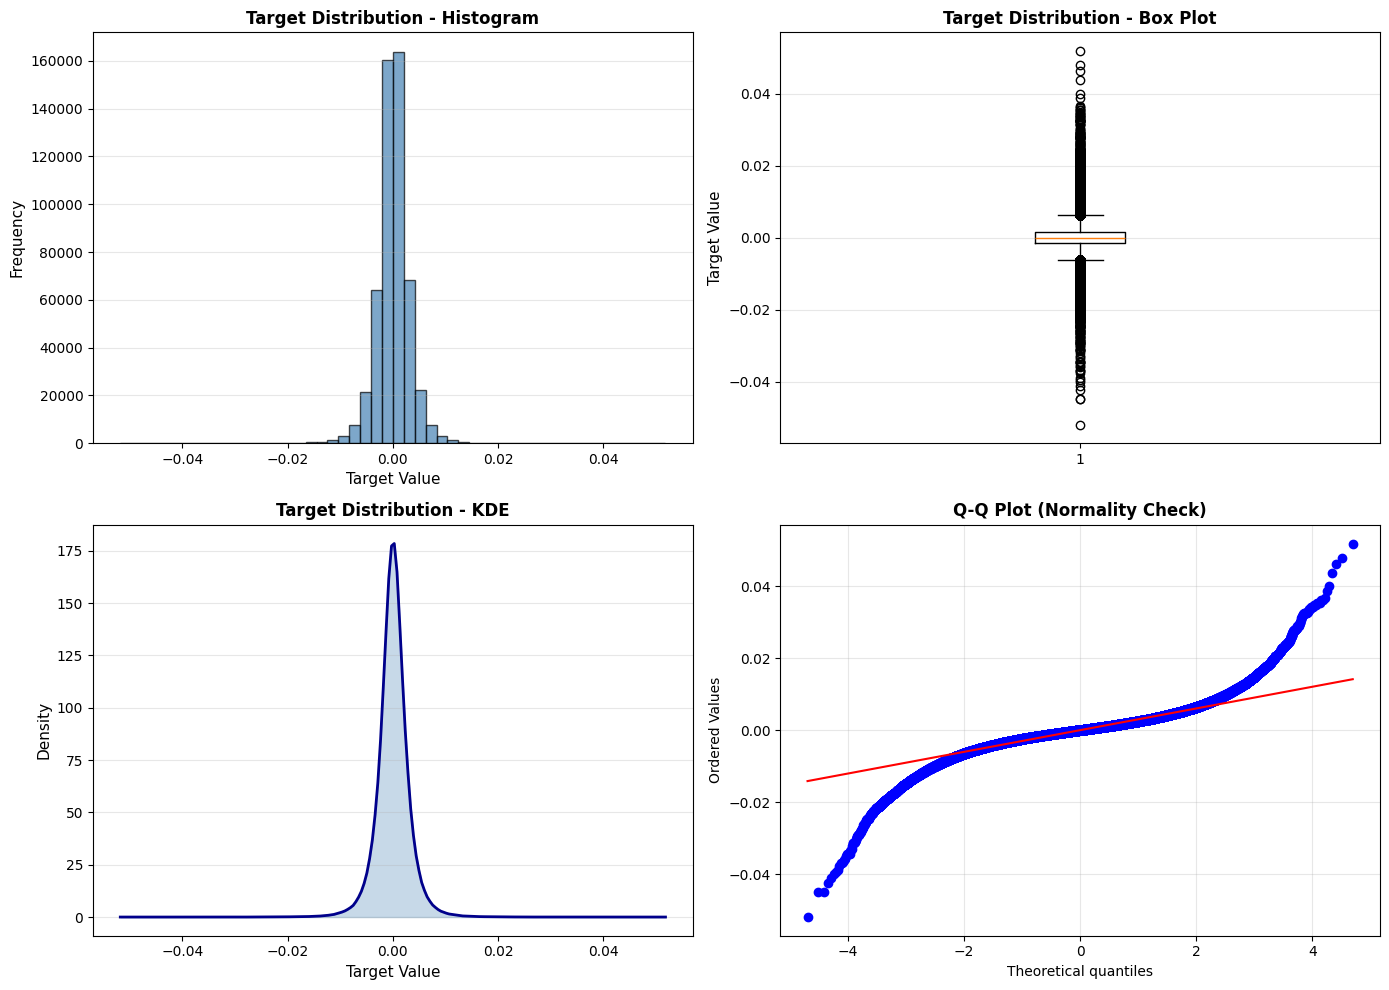


Target distribution visualized with 4 plots:


In [22]:
# Distribution of Target
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0, 0].hist(y_train_values, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('Target Value', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Target Distribution - Histogram', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Box plot
axes[0, 1].boxplot(y_train_values, vert=True)
axes[0, 1].set_ylabel('Target Value', fontsize=11)
axes[0, 1].set_title('Target Distribution - Box Plot', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# KDE plot
from scipy.stats import gaussian_kde
kde = gaussian_kde(y_train_values)
x_range = np.linspace(y_train_values.min(), y_train_values.max(), 200)
axes[1, 0].plot(x_range, kde(x_range), linewidth=2, color='darkblue')
axes[1, 0].fill_between(x_range, kde(x_range), alpha=0.3, color='steelblue')
axes[1, 0].set_xlabel('Target Value', fontsize=11)
axes[1, 0].set_ylabel('Density', fontsize=11)
axes[1, 0].set_title('Target Distribution - KDE', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Q-Q plot (for normality check)
from scipy import stats as sp_stats
sp_stats.probplot(y_train_values, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTarget distribution visualized with 4 plots:")


BINARY CLASSIFICATION ANALYSIS (Positive vs Negative Returns)

Class Distribution:
  Positive returns (target > 0): 267,323 (50.72%)
  Negative returns (target ≤ 0): 259,750 (49.28%)
  Class balance ratio: 1.0292
  ✓ Classes are well-balanced


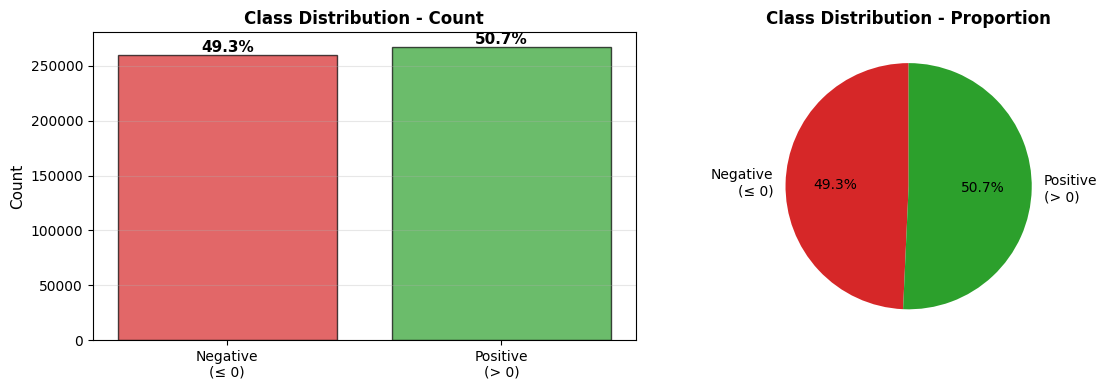


Class distribution visualized


In [23]:
# Binary Classification Analysis (if applicable)
print("\n" + "=" * 80)
print("BINARY CLASSIFICATION ANALYSIS (Positive vs Negative Returns)")
print("=" * 80)

# Convert to binary (positive vs negative)
y_binary = (y_train_values > 0).astype(int)

positive_count = (y_binary == 1).sum()
negative_count = (y_binary == 0).sum()
positive_pct = (positive_count / len(y_binary)) * 100
negative_pct = (negative_count / len(y_binary)) * 100

print(f"\nClass Distribution:")
print(f"  Positive returns (target > 0): {positive_count:,} ({positive_pct:.2f}%)")
print(f"  Negative returns (target ≤ 0): {negative_count:,} ({negative_pct:.2f}%)")
print(f"  Class balance ratio: {positive_count / negative_count:.4f}")

if abs(positive_pct - 50) > 10:
    print(f"  ⚠️  Classes are imbalanced (difference > 10%)")
else:
    print(f"  ✓ Classes are well-balanced")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
classes = ['Negative\n(≤ 0)', 'Positive\n(> 0)']
counts = [negative_count, positive_count]
colors = ['#d62728', '#2ca02c']
axes[0].bar(classes, counts, color=colors, edgecolor='black', alpha=0.7)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Class Distribution - Count', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, (c, pct) in enumerate(zip(counts, [negative_pct, positive_pct])):
    axes[0].text(i, c, f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Pie chart
axes[1].pie(counts, labels=classes, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Class Distribution - Proportion', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nClass distribution visualized")

In [24]:
# Summary Table
print("\n" + "=" * 80)
print("COMPREHENSIVE SUMMARY TABLE")
print("=" * 80)

summary_table = pd.DataFrame({
    'Metric': [
        'Total Samples',
        'Mean Return',
        'Median Return',
        'Std Dev',
        'Min Return',
        'Max Return',
        'Skewness',
        'Kurtosis',
        'Positive Returns (%)',
        'Negative Returns (%)',
        'Class Balance Ratio'
    ],
    'Value': [
        f"{len(y_train_values):,}",
        f"{y_train_values.mean():.6f}",
        f"{np.median(y_train_values):.6f}",
        f"{y_train_values.std():.6f}",
        f"{y_train_values.min():.6f}",
        f"{y_train_values.max():.6f}",
        f"{skewness_target:.4f}",
        f"{kurtosis_target:.4f}",
        f"{positive_pct:.2f}%",
        f"{negative_pct:.2f}%",
        f"{positive_count / negative_count:.4f}"
    ]
})

print(summary_table.to_string(index=False))


COMPREHENSIVE SUMMARY TABLE
              Metric     Value
       Total Samples   527,073
         Mean Return  0.000035
       Median Return  0.000041
             Std Dev  0.003106
          Min Return -0.051809
          Max Return  0.051803
            Skewness   -0.0024
            Kurtosis    7.7404
Positive Returns (%)    50.72%
Negative Returns (%)    49.28%
 Class Balance Ratio    1.0292


## Analysis of Interaction Features (Products, Divisions, Subtractions)

In [25]:
from scipy.stats import skew, kurtosis

# Recreate interaction features to analyze
top_features = [
    "RET_1",
    "RET_4",
    "ALLOCATIONS_AVERAGE_PERF_3",
    "ALLOCATIONS_AVERAGE_PERF_15",
    "ALLOCATIONS_AVERAGE_PERF_5",
]

interaction_features = []

# Products
for i, feat1 in enumerate(top_features):
    for feat2 in top_features[i + 1:]:
        feat_name = f"{feat1}_PROD_{feat2}"
        X_train[feat_name] = X_train[feat1] * X_train[feat2]
        interaction_features.append(feat_name)

# Divisions
for i, feat1 in enumerate(top_features):
    for feat2 in top_features[i + 1:]:
        feat_name = f"{feat1}_DIV_{feat2}"
        X_train[feat_name] = np.where(
            X_train[feat2] != 0, X_train[feat1] / (X_train[feat2] + 1e-8), 0
        )
        interaction_features.append(feat_name)

# Subtractions
for i, feat1 in enumerate(top_features):
    for feat2 in top_features[i + 1:]:
        feat_name = f"{feat1}_MINUS_{feat2}"
        X_train[feat_name] = X_train[feat1] - X_train[feat2]
        interaction_features.append(feat_name)

print(f"Created {len(interaction_features)} interaction features")
print(f"Interaction features: {interaction_features[:5]}...")  # Show first 5

Created 30 interaction features
Interaction features: ['RET_1_PROD_RET_4', 'RET_1_PROD_ALLOCATIONS_AVERAGE_PERF_3', 'RET_1_PROD_ALLOCATIONS_AVERAGE_PERF_15', 'RET_1_PROD_ALLOCATIONS_AVERAGE_PERF_5', 'RET_4_PROD_ALLOCATIONS_AVERAGE_PERF_3']...


In [26]:
# Calculate skewness and kurtosis for interaction features
print("\n" + "=" * 100)
print("INTERACTION FEATURES: SKEWNESS AND KURTOSIS ANALYSIS")
print("=" * 100)

interaction_stats = []

for feat in interaction_features:
    feat_data = X_train[feat].dropna()
    
    if len(feat_data) > 0:
        skewness = skew(feat_data)
        kurt = kurtosis(feat_data)
        missing_count = X_train[feat].isna().sum()
        missing_pct = (missing_count / len(X_train)) * 100
        
        interaction_stats.append({
            'Feature': feat,
            'Skewness': skewness,
            'Kurtosis': kurt,
            'Missing (%)': missing_pct,
            'Abs_Skew': abs(skewness),
            'Abs_Kurt': abs(kurt)
        })

interaction_df = pd.DataFrame(interaction_stats)

# Sort by absolute skewness
print("\nTop 15 Features by Absolute Skewness (candidates for transformation):")
print("-" * 100)
skew_sorted = interaction_df.sort_values('Abs_Skew', ascending=False).head(15)
print(skew_sorted[['Feature', 'Skewness', 'Kurtosis', 'Missing (%)']].to_string(index=False))

print("\n" + "-" * 100)
print("Top 15 Features by Absolute Kurtosis (tail heaviness):")
print("-" * 100)
kurt_sorted = interaction_df.sort_values('Abs_Kurt', ascending=False).head(15)
print(kurt_sorted[['Feature', 'Skewness', 'Kurtosis', 'Missing (%)']].to_string(index=False))


INTERACTION FEATURES: SKEWNESS AND KURTOSIS ANALYSIS

Top 15 Features by Absolute Skewness (candidates for transformation):
----------------------------------------------------------------------------------------------------
                                                    Feature    Skewness      Kurtosis  Missing (%)
                                            RET_1_DIV_RET_4 -580.964012 397882.932084          0.0
                       RET_4_DIV_ALLOCATIONS_AVERAGE_PERF_3   53.046506   4952.615989          0.0
 ALLOCATIONS_AVERAGE_PERF_15_DIV_ALLOCATIONS_AVERAGE_PERF_5  -50.387214   2542.263000          0.0
  ALLOCATIONS_AVERAGE_PERF_3_DIV_ALLOCATIONS_AVERAGE_PERF_5  -50.181494   2529.334894          0.0
                       RET_4_DIV_ALLOCATIONS_AVERAGE_PERF_5   40.729818   6934.639979          0.0
                      RET_4_DIV_ALLOCATIONS_AVERAGE_PERF_15   33.243060   6826.629098          0.0
                       RET_1_DIV_ALLOCATIONS_AVERAGE_PERF_3  -33.234886   3254.51


VISUALIZING TOP 12 FEATURES WITH HIGHEST SKEWNESS


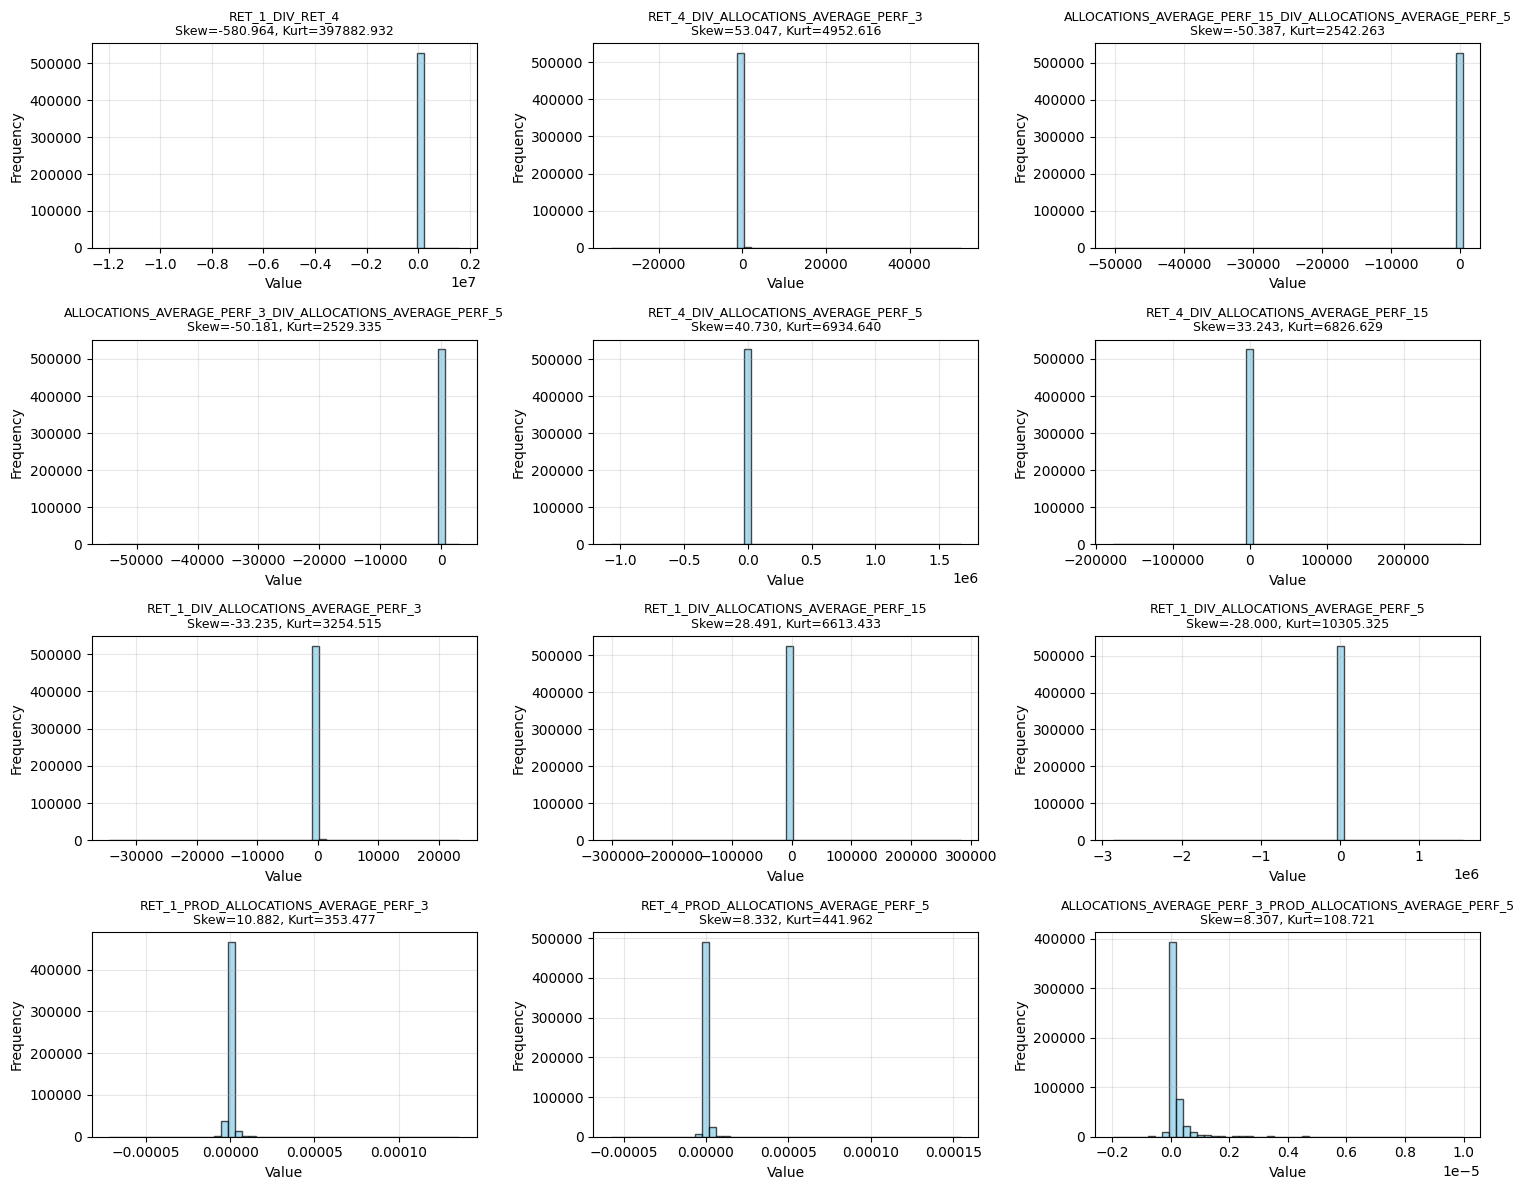

Features with |Skewness| > 1.0 (highly skewed) are good candidates for transformation


In [27]:
# Visualization: Distribution plots for top problematic features
print("\n" + "=" * 100)
print("VISUALIZING TOP 12 FEATURES WITH HIGHEST SKEWNESS")
print("=" * 100)

top_skewed_features = skew_sorted.head(12)['Feature'].tolist()

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, feat in enumerate(top_skewed_features):
    ax = axes[idx]
    data = X_train[feat].dropna()
    
    skewness_val = interaction_df[interaction_df['Feature'] == feat]['Skewness'].values[0]
    kurt_val = interaction_df[interaction_df['Feature'] == feat]['Kurtosis'].values[0]
    
    # Create histogram
    ax.hist(data, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    ax.set_title(f'{feat}\nSkew={skewness_val:.3f}, Kurt={kurt_val:.3f}', fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Features with |Skewness| > 1.0 (highly skewed) are good candidates for transformation")

In [28]:
# Categorize features by transformation recommendations
print("\n" + "=" * 100)
print("TRANSFORMATION RECOMMENDATIONS")
print("=" * 100)

highly_skewed = interaction_df[interaction_df['Abs_Skew'] > 1.0]
moderately_skewed = interaction_df[(interaction_df['Abs_Skew'] > 0.5) & (interaction_df['Abs_Skew'] <= 1.0)]
normal_dist = interaction_df[interaction_df['Abs_Skew'] <= 0.5]

print(f"\n1. HIGHLY SKEWED (|Skewness| > 1.0): {len(highly_skewed)} features")
print("   → Consider: Log transform, Box-Cox, or Yeo-Johnson transform")
if len(highly_skewed) > 0:
    print(highly_skewed[['Feature', 'Skewness', 'Kurtosis']].head(10).to_string(index=False))

print(f"\n2. MODERATELY SKEWED (0.5 < |Skewness| ≤ 1.0): {len(moderately_skewed)} features")
print("   → Consider: Mild transformations or scaling")
if len(moderately_skewed) > 0:
    print(moderately_skewed[['Feature', 'Skewness', 'Kurtosis']].head(10).to_string(index=False))

print(f"\n3. RELATIVELY NORMAL (|Skewness| ≤ 0.5): {len(normal_dist)} features")
print("   → No transformation needed, can use as-is")
if len(normal_dist) > 0:
    print(normal_dist[['Feature', 'Skewness', 'Kurtosis']].head(10).to_string(index=False))


TRANSFORMATION RECOMMENDATIONS

1. HIGHLY SKEWED (|Skewness| > 1.0): 19 features
   → Consider: Log transform, Box-Cox, or Yeo-Johnson transform
                                                    Feature    Skewness      Kurtosis
                      RET_1_PROD_ALLOCATIONS_AVERAGE_PERF_3   10.882168    353.477141
                     RET_1_PROD_ALLOCATIONS_AVERAGE_PERF_15    5.356981    162.249385
                      RET_1_PROD_ALLOCATIONS_AVERAGE_PERF_5    7.458541    248.064907
                      RET_4_PROD_ALLOCATIONS_AVERAGE_PERF_3    3.394590    390.601597
                     RET_4_PROD_ALLOCATIONS_AVERAGE_PERF_15    2.984800     85.649790
                      RET_4_PROD_ALLOCATIONS_AVERAGE_PERF_5    8.331606    441.961559
ALLOCATIONS_AVERAGE_PERF_3_PROD_ALLOCATIONS_AVERAGE_PERF_15    7.092420     88.894712
 ALLOCATIONS_AVERAGE_PERF_3_PROD_ALLOCATIONS_AVERAGE_PERF_5    8.306504    108.720684
ALLOCATIONS_AVERAGE_PERF_15_PROD_ALLOCATIONS_AVERAGE_PERF_5    6.283396     64.2

In [ ]:
# Categorize interaction features by correlation strength (updated thresholds)
print("\n" + "=" * 100)
print("INTERACTION FEATURES: CORRELATION STRENGTH CATEGORIES (Updated Thresholds)")
print("=" * 100)

strong_corr_int = correlation_with_target[correlation_with_target.abs() > 0.05]
moderate_corr_int = correlation_with_target[(correlation_with_target.abs() > 0.015) & (correlation_with_target.abs() <= 0.05)]
weak_corr_int = correlation_with_target[correlation_with_target.abs() <= 0.015]

print(f"\n1. STRONG CORRELATION (|corr| > 0.05): {len(strong_corr_int)} features")
print("   → These features have meaningful predictive power")
if len(strong_corr_int) > 0:
    for feat in strong_corr_int.sort_values(key=abs, ascending=False).head(10).index:
        print(f"     {feat:50s} : {correlation_with_target[feat]:8.6f}")

print(f"\n2. MODERATE CORRELATION (0.015 < |corr| ≤ 0.05): {len(moderate_corr_int)} features")
print("   → These features may have some predictive value")
if len(moderate_corr_int) > 0:
    print(f"     Showing first 5:")
    for feat in moderate_corr_int.sort_values(key=abs, ascending=False).head(5).index:
        print(f"     {feat:50s} : {correlation_with_target[feat]:8.6f}")

print(f"\n3. WEAK CORRELATION (|corr| ≤ 0.015): {len(weak_corr_int)} features")
print("   → Limited or no predictive power")
print(f"   → Consider removing or transforming these features")

# Recommendation
print(f"\n" + "=" * 100)
print("RECOMMENDATION")
print("=" * 100)
print(f"✓ Keep {len(strong_corr_int)} features with strong correlation (|corr| > 0.05)")
print(f"✓ Consider {len(moderate_corr_int)} features with moderate correlation for ensemble methods")
print(f"✓ Consider removing {len(weak_corr_int)} features with weak correlation (|corr| ≤ 0.015)")
print(f"✓ Prioritize features that combine strong correlation with low skewness")

## Comprehensive Correlation Analysis: All Features vs Target

In [32]:
# Rebuild all features for comprehensive analysis
RET_features = [f'RET_{i}' for i in range(1, 21)]
SIGNED_VOLUME_features = [f'SIGNED_VOLUME_{i}' for i in range(1, 21)]
TURNOVER_features = ['MEDIAN_DAILY_TURNOVER']

# Recreate engineered features
for i in [3, 5, 10, 15, 20]:
    if f'AVERAGE_PERF_{i}' not in X_train.columns:
        X_train[f'AVERAGE_PERF_{i}'] = X_train[RET_features[:i]].mean(1)
    if f'ALLOCATIONS_AVERAGE_PERF_{i}' not in X_train.columns:
        X_train[f'ALLOCATIONS_AVERAGE_PERF_{i}'] = X_train.groupby('TS')[f'AVERAGE_PERF_{i}'].transform('mean')

for i in [20]:
    if f'STD_PERF_{i}' not in X_train.columns:
        X_train[f'STD_PERF_{i}'] = X_train[RET_features[:i]].std(1)
    if f'ALLOCATIONS_STD_PERF_{i}' not in X_train.columns:
        X_train[f'ALLOCATIONS_STD_PERF_{i}'] = X_train.groupby('TS')[f'STD_PERF_{i}'].transform('mean')

# All feature categories
all_base_features = (
    RET_features + SIGNED_VOLUME_features + TURNOVER_features +
    [f'AVERAGE_PERF_{i}' for i in [3, 5, 10, 15, 20]] +
    [f'ALLOCATIONS_AVERAGE_PERF_{i}' for i in [3, 5, 10, 15, 20]] +
    [f'STD_PERF_{i}' for i in [20]] +
    [f'ALLOCATIONS_STD_PERF_{i}' for i in [20]]
)

all_features_combined = all_base_features + interaction_features

print(f"Base features: {len(all_base_features)}")
print(f"Interaction features: {len(interaction_features)}")
print(f"Total features: {len(all_features_combined)}")

# Compute correlations for all features
all_with_target = X_train[all_features_combined].copy()
all_with_target['target'] = y_train.values
all_correlations = all_with_target.corr()['target'].drop('target').sort_values(key=abs, ascending=False)

print(f"\n✓ Computed correlations for {len(all_correlations)} features")

Base features: 53
Interaction features: 30
Total features: 83

✓ Computed correlations for 83 features


In [33]:
# Categorize all features by type
base_feature_types = {
    'RET': RET_features,
    'SIGNED_VOLUME': SIGNED_VOLUME_features,
    'TURNOVER': TURNOVER_features,
    'AVERAGE_PERF': [f'AVERAGE_PERF_{i}' for i in [3, 5, 10, 15, 20]],
    'ALLOCATIONS_AVERAGE_PERF': [f'ALLOCATIONS_AVERAGE_PERF_{i}' for i in [3, 5, 10, 15, 20]],
    'STD_PERF': [f'STD_PERF_{i}' for i in [20]],
    'ALLOCATIONS_STD_PERF': [f'ALLOCATIONS_STD_PERF_{i}' for i in [20]],
    'INTERACTION': interaction_features
}

# Compute average correlation by feature type
print("\n" + "=" * 100)
print("AVERAGE CORRELATION BY FEATURE TYPE")
print("=" * 100 + "\n")

feature_type_stats = []
for feat_type, features_list in base_feature_types.items():
    valid_features = [f for f in features_list if f in all_correlations.index]
    if len(valid_features) > 0:
        corr_values = all_correlations[valid_features].abs()
        feature_type_stats.append({
            'Feature_Type': feat_type,
            'Count': len(valid_features),
            'Mean_Abs_Corr': corr_values.mean(),
            'Max_Corr': corr_values.max(),
            'Min_Corr': corr_values.min(),
            'Std_Corr': corr_values.std()
        })

type_stats_df = pd.DataFrame(feature_type_stats).sort_values('Mean_Abs_Corr', ascending=False)
print(type_stats_df.to_string(index=False))

print(f"\n{'Feature Type':<25} {'Rank':<6} {'Avg |Corr|':<15}")
print("-" * 46)
for idx, row in type_stats_df.iterrows():
    rank = idx + 1
    print(f"{row['Feature_Type']:<25} {rank:<6} {row['Mean_Abs_Corr']:<15.6f}")


AVERAGE CORRELATION BY FEATURE TYPE

            Feature_Type  Count  Mean_Abs_Corr  Max_Corr  Min_Corr  Std_Corr
            AVERAGE_PERF      5       0.028893  0.035303  0.016425  0.007560
             INTERACTION     30       0.022392  0.083898  0.000229  0.026662
ALLOCATIONS_AVERAGE_PERF      5       0.016676  0.024053  0.007869  0.006640
                TURNOVER      1       0.013405  0.013405  0.013405       NaN
                     RET     20       0.012796  0.084853  0.001416  0.018477
    ALLOCATIONS_STD_PERF      1       0.008255  0.008255  0.008255       NaN
           SIGNED_VOLUME     20       0.003957  0.007736  0.000024  0.002352
                STD_PERF      1       0.002032  0.002032  0.002032       NaN

Feature Type              Rank   Avg |Corr|     
----------------------------------------------
AVERAGE_PERF              4      0.028893       
INTERACTION               8      0.022392       
ALLOCATIONS_AVERAGE_PERF  5      0.016676       
TURNOVER                 


TOP 20 FEATURES BY ABSOLUTE CORRELATION WITH TARGET

 1. RET_4_PROD_ALLOCATIONS_AVERAGE_PERF_15             | -0.031882 | [✓ INTERACTION]
 2. RET_4_MINUS_ALLOCATIONS_AVERAGE_PERF_3             | -0.027917 | [✓ INTERACTION]
 3. RET_4_MINUS_ALLOCATIONS_AVERAGE_PERF_5             | -0.026036 | [✓ INTERACTION]
 4. RET_4_MINUS_ALLOCATIONS_AVERAGE_PERF_15            | -0.025748 | [✓ INTERACTION]
 5. RET_4                                              | -0.024339 | [RET]
 6. RET_7                                              | 0.021213 | [RET]
 7. ALLOCATIONS_AVERAGE_PERF_3                         | 0.024053 | [ALLOCATIONS_AVERAGE_PERF]
 8. ALLOCATIONS_AVERAGE_PERF_3_MINUS_ALLOCATIONS_AVERAGE_PERF_5 | 0.024266 | [✓ INTERACTION]
 9. AVERAGE_PERF_20                                    | 0.027590 | [AVERAGE_PERF]
10. AVERAGE_PERF_15                                    | 0.031290 | [AVERAGE_PERF]
11. RET_1_PROD_ALLOCATIONS_AVERAGE_PERF_5              | 0.032917 | [✓ INTERACTION]
12. RET_1_PROD_ALLO

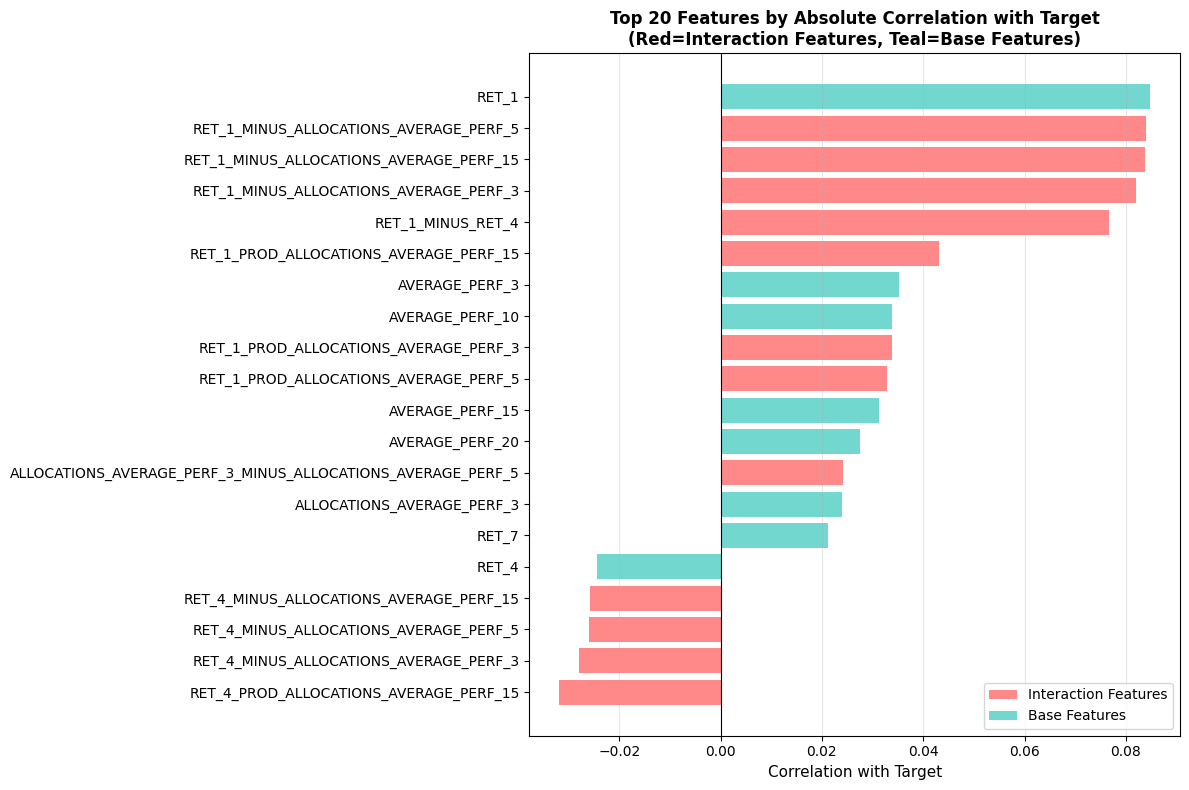

In [34]:
# Top 20 features overall
print("\n" + "=" * 100)
print("TOP 20 FEATURES BY ABSOLUTE CORRELATION WITH TARGET")
print("=" * 100 + "\n")

top_20_all = all_correlations.abs().nlargest(20)
top_20_sorted = all_correlations[top_20_all.index].sort_values(ascending=True)

for idx, (feat, corr_val) in enumerate(top_20_sorted.items(), 1):
    # Determine feature type
    feat_type = 'UNKNOWN'
    for ftype, flist in base_feature_types.items():
        if feat in flist:
            feat_type = ftype
            break
    
    marker = '✓ INTERACTION' if feat_type == 'INTERACTION' else feat_type
    print(f"{idx:2d}. {feat:50s} | {corr_val:8.6f} | [{marker}]")

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))
colors = []
for feat in top_20_sorted.index:
    if feat in interaction_features:
        colors.append('#FF6B6B')  # Red for interaction features
    else:
        colors.append('#4ECDC4')  # Teal for base features

ax.barh(range(len(top_20_sorted)), top_20_sorted.values, color=colors, alpha=0.8)
ax.set_yticks(range(len(top_20_sorted)))
ax.set_yticklabels(top_20_sorted.index, fontsize=10)
ax.set_xlabel('Correlation with Target', fontsize=11)
ax.set_title('Top 20 Features by Absolute Correlation with Target\n(Red=Interaction Features, Teal=Base Features)', 
             fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='x')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#FF6B6B', alpha=0.8, label='Interaction Features'),
                   Patch(facecolor='#4ECDC4', alpha=0.8, label='Base Features')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

In [36]:
# Distribution analysis by feature type
print("\n" + "=" * 100)
print("DISTRIBUTION OF CORRELATIONS BY FEATURE TYPE")
print("=" * 100 + "\n")

for feat_type in type_stats_df['Feature_Type']:
    features_list = base_feature_types[feat_type]
    valid_features = [f for f in features_list if f in all_correlations.index]
    
    if len(valid_features) > 0:
        corr_values = all_correlations[valid_features]
        
        strong = (corr_values.abs() > 0.05).sum()
        moderate = ((corr_values.abs() > 0.015) & (corr_values.abs() <= 0.05)).sum()
        weak = (corr_values.abs() <= 0.015).sum()
        
        print(f"{feat_type:<25} (n={len(valid_features):2d})")
        print(f"  Strong (|corr| > 0.05):        {strong:2d} ({strong/len(valid_features)*100:5.1f}%)")
        print(f"  Moderate (0.015 < |corr| ≤ 0.05): {moderate:2d} ({moderate/len(valid_features)*100:5.1f}%)")
        print(f"  Weak (|corr| ≤ 0.015):         {weak:2d} ({weak/len(valid_features)*100:5.1f}%)")
        print()

# Final summary
print("=" * 100)
print("KEY INSIGHTS")
print("=" * 100)
interaction_corr = all_correlations[interaction_features].abs()
base_corr = all_correlations[all_base_features].abs()

print(f"\nInteraction Features vs Base Features:")
print(f"  Avg |Correlation| - Interaction: {interaction_corr.mean():.6f}")
print(f"  Avg |Correlation| - Base:        {base_corr.mean():.6f}")
print(f"  Better by:                       {(interaction_corr.mean() - base_corr.mean()):.6f} ({((interaction_corr.mean() - base_corr.mean())/base_corr.mean()*100):+.1f}%)")

# Count features with strong correlation
strong_interaction = (interaction_corr > 0.05).sum()
strong_base = (base_corr > 0.05).sum()

print(f"\nStrong Correlation Features (|corr| > 0.05):")
print(f"  Interaction: {strong_interaction} / {len(interaction_features)} ({strong_interaction/len(interaction_features)*100:.1f}%)")
print(f"  Base:        {strong_base} / {len(all_base_features)} ({strong_base/len(all_base_features)*100:.1f}%)")


DISTRIBUTION OF CORRELATIONS BY FEATURE TYPE

AVERAGE_PERF              (n= 5)
  Strong (|corr| > 0.05):         0 (  0.0%)
  Moderate (0.015 < |corr| ≤ 0.05):  5 (100.0%)
  Weak (|corr| ≤ 0.015):          0 (  0.0%)

INTERACTION               (n=30)
  Strong (|corr| > 0.05):         4 ( 13.3%)
  Moderate (0.015 < |corr| ≤ 0.05): 11 ( 36.7%)
  Weak (|corr| ≤ 0.015):         15 ( 50.0%)

ALLOCATIONS_AVERAGE_PERF  (n= 5)
  Strong (|corr| > 0.05):         0 (  0.0%)
  Moderate (0.015 < |corr| ≤ 0.05):  3 ( 60.0%)
  Weak (|corr| ≤ 0.015):          2 ( 40.0%)

TURNOVER                  (n= 1)
  Strong (|corr| > 0.05):         0 (  0.0%)
  Moderate (0.015 < |corr| ≤ 0.05):  0 (  0.0%)
  Weak (|corr| ≤ 0.015):          1 (100.0%)

RET                       (n=20)
  Strong (|corr| > 0.05):         1 (  5.0%)
  Moderate (0.015 < |corr| ≤ 0.05):  4 ( 20.0%)
  Weak (|corr| ≤ 0.015):         15 ( 75.0%)

ALLOCATIONS_STD_PERF      (n= 1)
  Strong (|corr| > 0.05):         0 (  0.0%)
  Moderate (0.0

In [37]:
# List all features with correlation > 0.015
print("\n" + "=" * 100)
print("ALL FEATURES WITH |CORRELATION| > 0.015")
print("=" * 100 + "\n")

features_above_threshold = all_correlations[all_correlations.abs() > 0.015].sort_values(ascending=False)

print(f"Total features with |corr| > 0.015: {len(features_above_threshold)}\n")

# Create a formatted table
print(f"{'Rank':<6} {'Feature':<50} {'Correlation':<15} {'Type':<20}")
print("-" * 91)

for idx, (feat, corr_val) in enumerate(features_above_threshold.items(), 1):
    # Determine feature type
    feat_type = 'UNKNOWN'
    for ftype, flist in base_feature_types.items():
        if feat in flist:
            feat_type = ftype
            break
    
    print(f"{idx:<6} {feat:<50} {corr_val:>14.6f} {feat_type:<20}")

# Summary statistics
print("\n" + "=" * 100)
print("SUMMARY")
print("=" * 100)
print(f"Total features analyzed: {len(all_correlations)}")
print(f"Features with |corr| > 0.015: {len(features_above_threshold)} ({len(features_above_threshold)/len(all_correlations)*100:.1f}%)")
print(f"Features with |corr| ≤ 0.015: {len(all_correlations) - len(features_above_threshold)} ({(len(all_correlations) - len(features_above_threshold))/len(all_correlations)*100:.1f}%)")

# Breakdown by correlation strength
strong_above = (features_above_threshold.abs() > 0.05).sum()
moderate_above = ((features_above_threshold.abs() > 0.015) & (features_above_threshold.abs() <= 0.05)).sum()

print(f"\nBreakdown of features with |corr| > 0.015:")
print(f"  Strong (|corr| > 0.05):          {strong_above} features")
print(f"  Moderate (0.015 < |corr| ≤ 0.05): {moderate_above} features")


ALL FEATURES WITH |CORRELATION| > 0.015

Total features with |corr| > 0.015: 28

Rank   Feature                                            Correlation     Type                
-------------------------------------------------------------------------------------------
1      RET_1                                                    0.084853 RET                 
2      RET_1_MINUS_ALLOCATIONS_AVERAGE_PERF_5                   0.083898 INTERACTION         
3      RET_1_MINUS_ALLOCATIONS_AVERAGE_PERF_15                  0.083748 INTERACTION         
4      RET_1_MINUS_ALLOCATIONS_AVERAGE_PERF_3                   0.081970 INTERACTION         
5      RET_1_MINUS_RET_4                                        0.076677 INTERACTION         
6      RET_1_PROD_ALLOCATIONS_AVERAGE_PERF_15                   0.043153 INTERACTION         
7      AVERAGE_PERF_3                                           0.035303 AVERAGE_PERF        
8      AVERAGE_PERF_10                                          0.033856 

## Intra-Feature Correlation Analysis (Multicollinearity Check)

INTRA-FEATURE CORRELATION ANALYSIS (Multicollinearity Detection)

Analyzing 83 features (ALL features)

HIGHLY CORRELATED PAIRS (|r| > 0.7): 40 pairs found

                                                   Feature_1                                                    Feature_2  Correlation
                                                       RET_4                      RET_4_MINUS_ALLOCATIONS_AVERAGE_PERF_15     0.997453
                                                       RET_1                      RET_1_MINUS_ALLOCATIONS_AVERAGE_PERF_15     0.997436
                      RET_4_MINUS_ALLOCATIONS_AVERAGE_PERF_3                       RET_4_MINUS_ALLOCATIONS_AVERAGE_PERF_5     0.995356
                     RET_4_MINUS_ALLOCATIONS_AVERAGE_PERF_15                       RET_4_MINUS_ALLOCATIONS_AVERAGE_PERF_5     0.995160
                     RET_1_MINUS_ALLOCATIONS_AVERAGE_PERF_15                       RET_1_MINUS_ALLOCATIONS_AVERAGE_PERF_5     0.995128
                      RET_1_MINUS

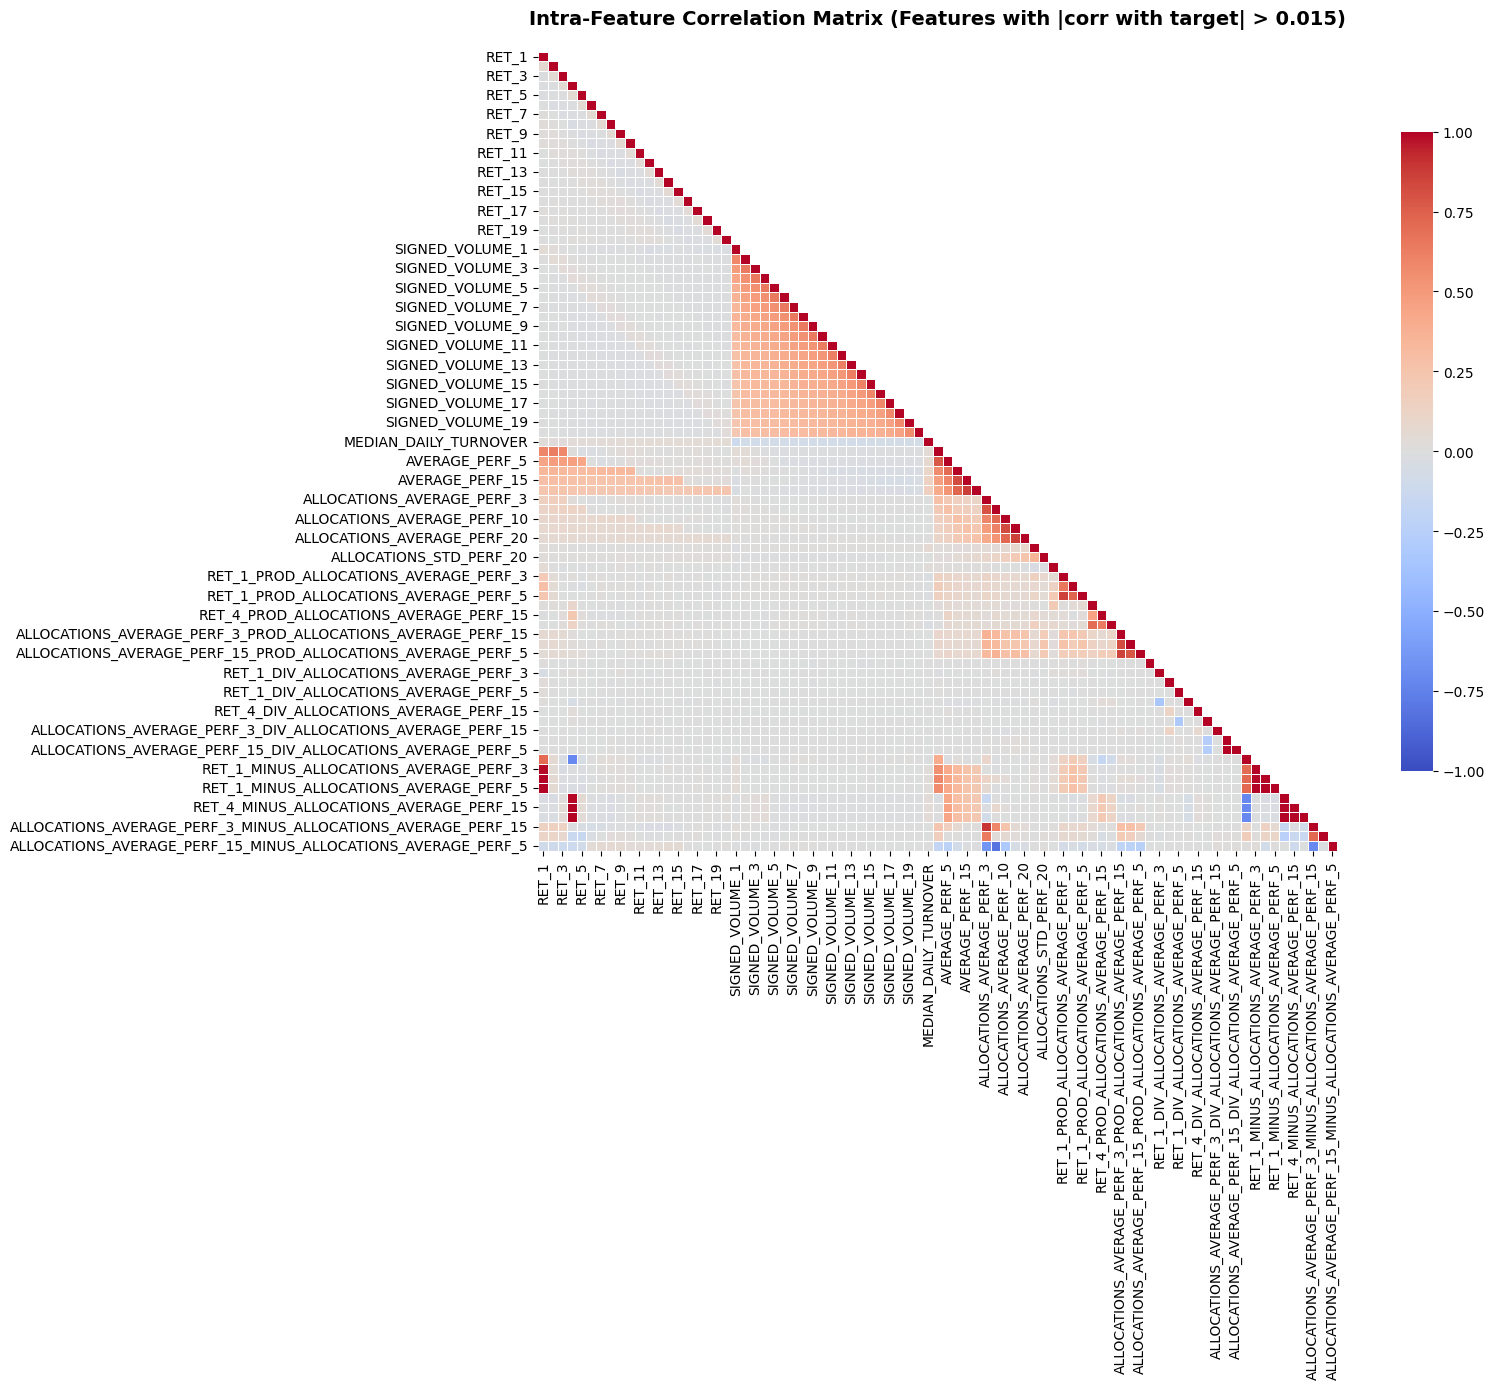


SUMMARY STATISTICS

Total feature pairs: 3403
Mean absolute correlation between features: 0.063618
Median absolute correlation: 0.010341
Std of correlations: 0.143269
Max correlation: 0.997453
Min correlation: 0.000001

Distribution by strength:
  Very High (|r| > 0.9):      13 pairs (  0.4%)
  High (0.7 < |r| ≤ 0.9):    27 pairs (  0.8%)
  Moderate (0.5 < |r| ≤ 0.7):  48 pairs (  1.4%)
  Low (0.3 < |r| ≤ 0.5):    178 pairs (  5.2%)
  Very Low (|r| ≤ 0.3):      3137 pairs ( 92.2%)

✓ Multicollinearity assessment: LOW risk


In [39]:
# Compute intra-feature correlation matrix
print("=" * 100)
print("INTRA-FEATURE CORRELATION ANALYSIS (Multicollinearity Detection)")
print("=" * 100 + "\n")

# Use ALL features for analysis
features_to_analyze = all_features_combined
feature_subset = X_train[features_to_analyze].copy()

# Compute correlation matrix
intra_corr_matrix = feature_subset.corr()

print(f"Analyzing {len(features_to_analyze)} features (ALL features)\n")

# Find highly correlated feature pairs (|r| > 0.7, excluding diagonal)
highly_correlated_pairs = []
for i in range(len(intra_corr_matrix.columns)):
    for j in range(i + 1, len(intra_corr_matrix.columns)):
        corr_val = intra_corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            highly_correlated_pairs.append({
                'Feature_1': intra_corr_matrix.columns[i],
                'Feature_2': intra_corr_matrix.columns[j],
                'Correlation': corr_val
            })

highly_corr_df = pd.DataFrame(highly_correlated_pairs).sort_values('Correlation', key=abs, ascending=False)

if len(highly_corr_df) > 0:
    print(f"HIGHLY CORRELATED PAIRS (|r| > 0.7): {len(highly_corr_df)} pairs found\n")
    print(highly_corr_df.to_string(index=False))
else:
    print("✓ No highly correlated pairs (|r| > 0.7) found - good multicollinearity profile!\n")

# Find moderately correlated pairs (0.5 < |r| <= 0.7)
moderately_correlated_pairs = []
for i in range(len(intra_corr_matrix.columns)):
    for j in range(i + 1, len(intra_corr_matrix.columns)):
        corr_val = intra_corr_matrix.iloc[i, j]
        if 0.5 < abs(corr_val) <= 0.7:
            moderately_correlated_pairs.append({
                'Feature_1': intra_corr_matrix.columns[i],
                'Feature_2': intra_corr_matrix.columns[j],
                'Correlation': corr_val
            })

moderately_corr_df = pd.DataFrame(moderately_correlated_pairs).sort_values('Correlation', key=abs, ascending=False)

if len(moderately_corr_df) > 0:
    print(f"\nMODERATELY CORRELATED PAIRS (0.5 < |r| ≤ 0.7): {len(moderately_corr_df)} pairs found")
    print("(showing top 15)")
    print(moderately_corr_df.head(15).to_string(index=False))
else:
    print(f"\nNo moderately correlated pairs (0.5 < |r| ≤ 0.7) found\n")

# Feature redundancy analysis: Average correlation with other features
print("\n" + "=" * 100)
print("FEATURE REDUNDANCY ANALYSIS (Average Intra-Feature Correlation)")
print("=" * 100 + "\n")

feature_redundancy = []
for feat in features_to_analyze:
    # Get correlations with other features (excluding self)
    other_corrs = intra_corr_matrix[feat].drop(feat).abs()
    
    feature_redundancy.append({
        'Feature': feat,
        'Mean_Corr_with_Others': other_corrs.mean(),
        'Max_Corr': other_corrs.max(),
        'Min_Corr': other_corrs.min(),
        'Std_Corr': other_corrs.std(),
        'High_Corr_Count': (other_corrs > 0.7).sum(),
        'Moderate_Corr_Count': ((other_corrs > 0.5) & (other_corrs <= 0.7)).sum()
    })

redundancy_df = pd.DataFrame(feature_redundancy).sort_values('Mean_Corr_with_Others', ascending=False)

print("Top 15 features by average correlation with other features:")
print("-" * 100)
print(redundancy_df.head(15)[['Feature', 'Mean_Corr_with_Others', 'Max_Corr', 'High_Corr_Count', 'Moderate_Corr_Count']].to_string(index=False))

print("\n" + "-" * 100)
print("Features with LOWEST average correlation (most independent):")
print("-" * 100)
print(redundancy_df.tail(10)[['Feature', 'Mean_Corr_with_Others', 'Max_Corr', 'High_Corr_Count', 'Moderate_Corr_Count']].to_string(index=False))

# Visualization: Heatmap of intra-feature correlations
fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(intra_corr_matrix, dtype=bool), k=1)
sns.heatmap(intra_corr_matrix, mask=mask, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax,
            vmin=-1, vmax=1, annot=False)
ax.set_title('Intra-Feature Correlation Matrix (Features with |corr with target| > 0.015)', 
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "=" * 100)
print("SUMMARY STATISTICS")
print("=" * 100)
all_pairwise_corrs = []
for i in range(len(intra_corr_matrix.columns)):
    for j in range(i + 1, len(intra_corr_matrix.columns)):
        all_pairwise_corrs.append(abs(intra_corr_matrix.iloc[i, j]))

all_pairwise_corrs = pd.Series(all_pairwise_corrs)

print(f"\nTotal feature pairs: {len(all_pairwise_corrs)}")
print(f"Mean absolute correlation between features: {all_pairwise_corrs.mean():.6f}")
print(f"Median absolute correlation: {all_pairwise_corrs.median():.6f}")
print(f"Std of correlations: {all_pairwise_corrs.std():.6f}")
print(f"Max correlation: {all_pairwise_corrs.max():.6f}")
print(f"Min correlation: {all_pairwise_corrs.min():.6f}")

print(f"\nDistribution by strength:")
print(f"  Very High (|r| > 0.9):     {(all_pairwise_corrs > 0.9).sum():3d} pairs ({(all_pairwise_corrs > 0.9).sum()/len(all_pairwise_corrs)*100:5.1f}%)")
print(f"  High (0.7 < |r| ≤ 0.9):   {((all_pairwise_corrs > 0.7) & (all_pairwise_corrs <= 0.9)).sum():3d} pairs ({((all_pairwise_corrs > 0.7) & (all_pairwise_corrs <= 0.9)).sum()/len(all_pairwise_corrs)*100:5.1f}%)")
print(f"  Moderate (0.5 < |r| ≤ 0.7): {((all_pairwise_corrs > 0.5) & (all_pairwise_corrs <= 0.7)).sum():3d} pairs ({((all_pairwise_corrs > 0.5) & (all_pairwise_corrs <= 0.7)).sum()/len(all_pairwise_corrs)*100:5.1f}%)")
print(f"  Low (0.3 < |r| ≤ 0.5):    {((all_pairwise_corrs > 0.3) & (all_pairwise_corrs <= 0.5)).sum():3d} pairs ({((all_pairwise_corrs > 0.3) & (all_pairwise_corrs <= 0.5)).sum()/len(all_pairwise_corrs)*100:5.1f}%)")
print(f"  Very Low (|r| ≤ 0.3):      {(all_pairwise_corrs <= 0.3).sum():3d} pairs ({(all_pairwise_corrs <= 0.3).sum()/len(all_pairwise_corrs)*100:5.1f}%)")

print(f"\n✓ Multicollinearity assessment: {'LOW risk' if all_pairwise_corrs.mean() < 0.4 else 'MODERATE risk' if all_pairwise_corrs.mean() < 0.6 else 'HIGH risk'}")

## Feature Selection Demo: Removing Redundant Features

In [42]:
# Feature selection algorithm: Remove redundant features while keeping most predictive ones
print("=" * 100)
print("FEATURE SELECTION: ALGORITHM DEMONSTRATION")
print("=" * 100 + "\n")

# Start with all features
remaining_features = set(all_features_combined)
removed_features = []
removal_reasons = []

print("STEP 1: Identifying highly correlated pairs (|r| > 0.7)")
print("-" * 100)

# Find and process highly correlated pairs
processed_pairs = set()
for i in range(len(intra_corr_matrix.columns)):
    for j in range(i + 1, len(intra_corr_matrix.columns)):
        feat1 = intra_corr_matrix.columns[i]
        feat2 = intra_corr_matrix.columns[j]
        corr_val = intra_corr_matrix.iloc[i, j]
        
        # Skip if pair already processed or if features already removed
        pair_key = tuple(sorted([feat1, feat2]))
        if pair_key in processed_pairs or feat1 not in remaining_features or feat2 not in remaining_features:
            continue
        
        if abs(corr_val) > 0.7:
            processed_pairs.add(pair_key)
            
            # Get target correlations
            corr_target_1 = abs(all_correlations[feat1]) if feat1 in all_correlations.index else 0
            corr_target_2 = abs(all_correlations[feat2]) if feat2 in all_correlations.index else 0
            
            # Keep the one with higher target correlation
            if corr_target_1 >= corr_target_2:
                to_remove = feat2
                to_keep = feat1
            else:
                to_remove = feat1
                to_keep = feat2
            
            remaining_features.discard(to_remove)
            removed_features.append(to_remove)
            removal_reasons.append({
                'Removed': to_remove,
                'Kept': to_keep,
                'Intra_Correlation': corr_val,
                'Target_Corr_Removed': corr_target_1 if to_remove == feat1 else corr_target_2,
                'Target_Corr_Kept': corr_target_1 if to_keep == feat1 else corr_target_2,
                'Reason': 'Highly correlated with another feature'
            })
            print(f"  {to_remove:50s} → REMOVED (intra-corr: {abs(corr_val):.4f}, target-corr: {corr_target_1 if to_remove == feat1 else corr_target_2:.4f})")
            print(f"  {to_keep:50s} → KEPT (intra-corr: {abs(corr_val):.4f}, target-corr: {corr_target_1 if to_keep == feat1 else corr_target_2:.4f})")
            print()

print(f"\n✓ Removed {len(removed_features)} features due to high correlation")
print(f"✓ Remaining features: {len(remaining_features)}\n")

# STEP 2: Filter by target correlation (keep only |corr| > 0.015)
print("\nSTEP 2: Filtering by target correlation (keep |corr| > 0.015)")
print("-" * 100)

features_removed_weak_corr = []
for feat in list(remaining_features):
    feat_target_corr = abs(all_correlations[feat]) if feat in all_correlations.index else 0
    if feat_target_corr <= 0.015:
        features_removed_weak_corr.append((feat, feat_target_corr))
        remaining_features.discard(feat)
        removed_features.append(feat)
        print(f"  {feat:50s} → REMOVED (target-corr: {feat_target_corr:.6f})")

print(f"\n✓ Removed {len(features_removed_weak_corr)} features due to weak target correlation (|corr| ≤ 0.015)")
print(f"✓ Remaining features: {len(remaining_features)}\n")

# Analyze independence of remaining features
print("\nSTEP 3: Analyzing independence of remaining features")
print("-" * 100)

selected_features_list = sorted(list(remaining_features))
selected_intra_corr = intra_corr_matrix.loc[selected_features_list, selected_features_list]

# Calculate average correlation for each feature among remaining features
independence_scores = []
for feat in selected_features_list:
    other_corrs = selected_intra_corr[feat].drop(feat).abs()
    mean_corr = other_corrs.mean()
    max_corr = other_corrs.max()
    high_corr_count = (other_corrs > 0.5).sum()
    
    independence_scores.append({
        'Feature': feat,
        'Mean_Intra_Corr': mean_corr,
        'Max_Intra_Corr': max_corr,
        'High_Corr_Count': high_corr_count,
        'Target_Corr': abs(all_correlations[feat]) if feat in all_correlations.index else 0
    })

independence_df = pd.DataFrame(independence_scores).sort_values('Mean_Intra_Corr')

print(f"\nMost INDEPENDENT features (lowest average intra-correlation):")
print("-" * 100)
print(independence_df.head(10)[['Feature', 'Mean_Intra_Corr', 'Max_Intra_Corr', 'Target_Corr']].to_string(index=False))

print(f"\n\nMost REDUNDANT features (highest average intra-correlation):")
print("-" * 100)
print(independence_df.tail(10)[['Feature', 'Mean_Intra_Corr', 'Max_Intra_Corr', 'Target_Corr']].to_string(index=False))

# Summary statistics
print("\n" + "=" * 100)
print("FEATURE SELECTION SUMMARY")
print("=" * 100)
print(f"\nOriginal features:                   {len(all_features_combined)}")
print(f"Removed due to redundancy:           {len(removal_reasons)}")
print(f"Removed due to weak target corr:     {len(features_removed_weak_corr)}")
print(f"Total removed:                       {len(removed_features)}")
print(f"Selected features:                   {len(remaining_features)}")
print(f"Reduction:                           {len(removed_features)/len(all_features_combined)*100:.1f}%")

# Analyze selected features by type
print(f"\nSelected features by type:")
print("-" * 100)
for feat_type, features_list in base_feature_types.items():
    selected_in_type = [f for f in features_list if f in remaining_features]
    original_in_type = len(features_list)
    print(f"  {feat_type:<25} : {len(selected_in_type):2d} / {original_in_type:2d} ({len(selected_in_type)/original_in_type*100:5.1f}%)")

# Target correlation statistics for selected features
selected_target_corrs = all_correlations[list(remaining_features)]
print(f"\nTarget correlation statistics for selected features:")
print("-" * 100)
print(f"  Mean |correlation|:  {selected_target_corrs.abs().mean():.6f}")
print(f"  Median |correlation|: {selected_target_corrs.abs().median():.6f}")
print(f"  Max |correlation|:   {selected_target_corrs.abs().max():.6f}")
print(f"  Min |correlation|:   {selected_target_corrs.abs().min():.6f}")
print(f"  Std:                  {selected_target_corrs.abs().std():.6f}")

# Comparison with all features
all_target_corrs = all_correlations[all_features_combined]
print(f"\nComparison with ALL features:")
print(f"  All features mean |corr|:      {all_target_corrs.abs().mean():.6f}")
print(f"  Selected features mean |corr|: {selected_target_corrs.abs().mean():.6f}")
print(f"  Improvement:                   {((selected_target_corrs.abs().mean() - all_target_corrs.abs().mean()) / all_target_corrs.abs().mean() * 100):+.1f}%")

print(f"\n✓ FINAL SELECTED FEATURES (non-redundant + |target-corr| > 0.015):")
print(f"\nCount: {len(selected_features_list)}")
print(f"\n{sorted(selected_features_list)}")


FEATURE SELECTION: ALGORITHM DEMONSTRATION

STEP 1: Identifying highly correlated pairs (|r| > 0.7)
----------------------------------------------------------------------------------------------------
  RET_1_MINUS_RET_4                                  → REMOVED (intra-corr: 0.7102, target-corr: 0.0767)
  RET_1                                              → KEPT (intra-corr: 0.7102, target-corr: 0.0849)

  RET_1_MINUS_ALLOCATIONS_AVERAGE_PERF_3             → REMOVED (intra-corr: 0.9869, target-corr: 0.0820)
  RET_1                                              → KEPT (intra-corr: 0.9869, target-corr: 0.0849)

  RET_1_MINUS_ALLOCATIONS_AVERAGE_PERF_15            → REMOVED (intra-corr: 0.9974, target-corr: 0.0837)
  RET_1                                              → KEPT (intra-corr: 0.9974, target-corr: 0.0849)

  RET_1_MINUS_ALLOCATIONS_AVERAGE_PERF_5             → REMOVED (intra-corr: 0.9922, target-corr: 0.0839)
  RET_1                                              → KEPT (intra-cor

## Kurtosis analysis

KURTOSIS ANALYSIS OF SELECTED FEATURES

Total selected features analyzed: 19

DETAILED KURTOSIS STATISTICS

Feature                                                Kurtosis    Abs(Kurt)     Skewness
----------------------------------------------------------------------------------------------------
RET_4_PROD_ALLOCATIONS_AVERAGE_PERF_5                441.961559   441.961559     8.331630
RET_4_PROD_ALLOCATIONS_AVERAGE_PERF_3                390.601597   390.601597     3.394599
RET_1_PROD_ALLOCATIONS_AVERAGE_PERF_3                353.477141   353.477141    10.882199
SIGNED_VOLUME_1                                      211.427270   211.427270    -3.897994
RET_1_PROD_ALLOCATIONS_AVERAGE_PERF_15               162.249385   162.249385     5.356996
RET_4_PROD_ALLOCATIONS_AVERAGE_PERF_15                85.649790    85.649790     2.984808
MEDIAN_DAILY_TURNOVER                                 19.642388    19.642388     4.322450
RET_1                                                 18.439956    18.4

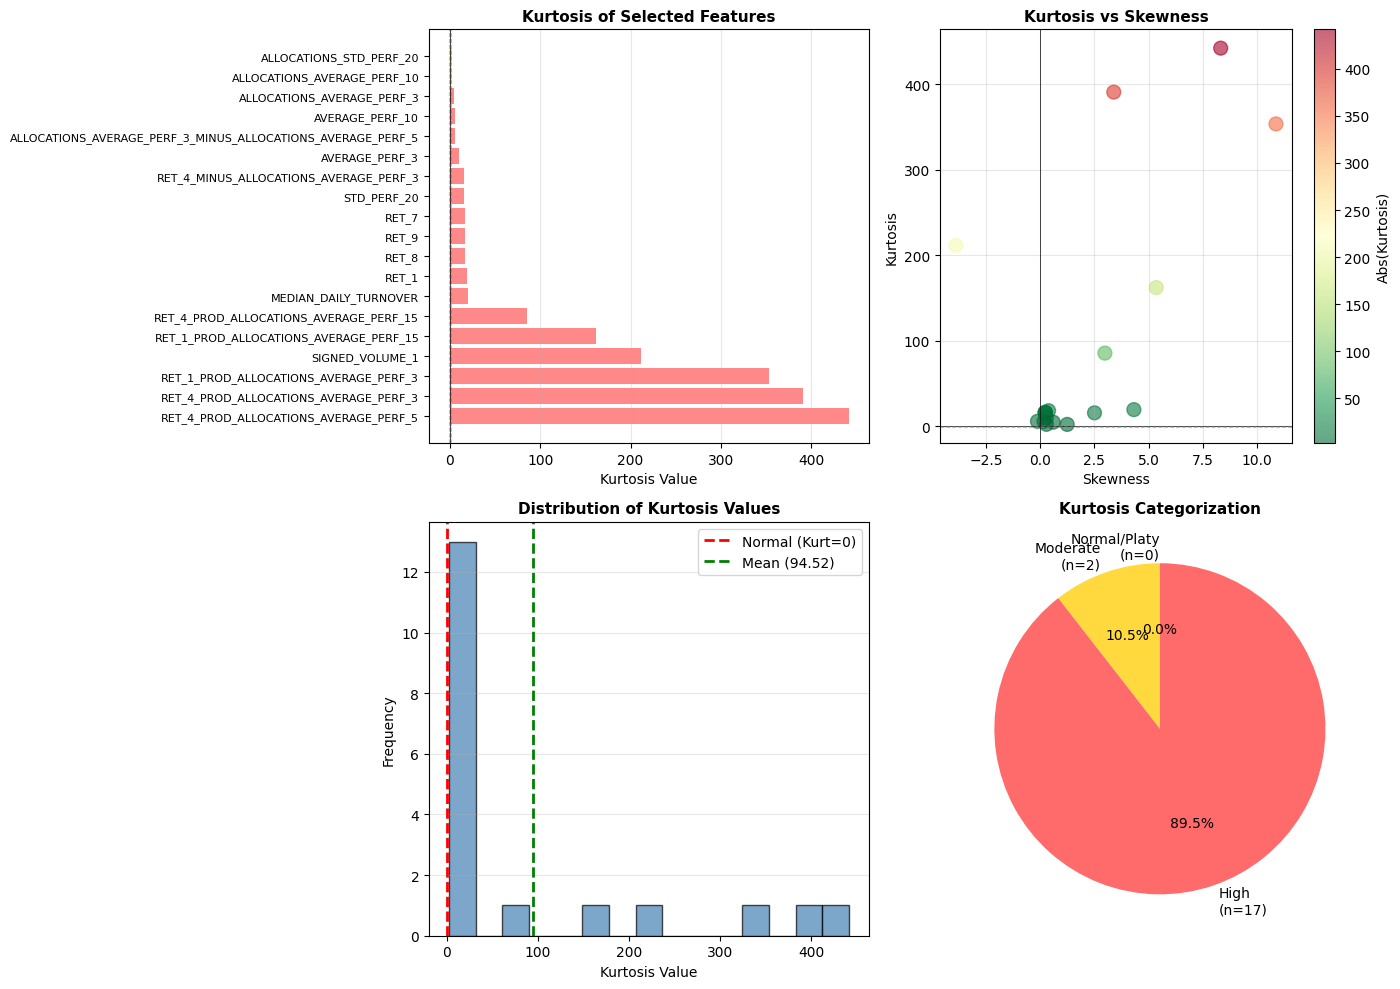


✓ Kurtosis analysis complete for 19 selected features


In [43]:
# Kurtosis analysis of selected features
from scipy.stats import kurtosis

print("=" * 100)
print("KURTOSIS ANALYSIS OF SELECTED FEATURES")
print("=" * 100 + "\n")

# Selected features from feature engineering
selected_features_final = [
    'ALLOCATIONS_AVERAGE_PERF_10',
    'ALLOCATIONS_AVERAGE_PERF_3',
    'ALLOCATIONS_AVERAGE_PERF_3_MINUS_ALLOCATIONS_AVERAGE_PERF_5',
    'AVERAGE_PERF_10',
    'AVERAGE_PERF_3',
    'RET_1',
    'RET_1_PROD_ALLOCATIONS_AVERAGE_PERF_15',
    'RET_1_PROD_ALLOCATIONS_AVERAGE_PERF_3',
    'RET_4_MINUS_ALLOCATIONS_AVERAGE_PERF_3',
    'RET_4_PROD_ALLOCATIONS_AVERAGE_PERF_15',
    'RET_4_PROD_ALLOCATIONS_AVERAGE_PERF_3',
    'RET_4_PROD_ALLOCATIONS_AVERAGE_PERF_5',
    'RET_7',
    'RET_8',
    'RET_9',
    'SIGNED_VOLUME_1',
    'MEDIAN_DAILY_TURNOVER',
    'STD_PERF_20',
    'ALLOCATIONS_STD_PERF_20'
]

# Compute kurtosis for selected features
kurtosis_stats = []
for feat in selected_features_final:
    if feat in X_train.columns:
        feat_data = X_train[feat].dropna()
        kurt_val = kurtosis(feat_data)
        skew_val = feat_data.skew()
        mean_val = feat_data.mean()
        std_val = feat_data.std()
        
        kurtosis_stats.append({
            'Feature': feat,
            'Kurtosis': kurt_val,
            'Skewness': skew_val,
            'Mean': mean_val,
            'Std': std_val,
            'Abs_Kurtosis': abs(kurt_val)
        })

kurtosis_df = pd.DataFrame(kurtosis_stats).sort_values('Abs_Kurtosis', ascending=False)

print(f"Total selected features analyzed: {len(kurtosis_df)}\n")

# Detailed table
print("=" * 100)
print("DETAILED KURTOSIS STATISTICS")
print("=" * 100)
print(f"\n{'Feature':<50} {'Kurtosis':>12} {'Abs(Kurt)':>12} {'Skewness':>12}")
print("-" * 100)
for idx, row in kurtosis_df.iterrows():
    print(f"{row['Feature']:<50} {row['Kurtosis']:>12.6f} {row['Abs_Kurtosis']:>12.6f} {row['Skewness']:>12.6f}")

# Summary statistics
print("\n" + "=" * 100)
print("SUMMARY STATISTICS")
print("=" * 100)
print(f"\nMean Kurtosis:               {kurtosis_df['Kurtosis'].mean():.6f}")
print(f"Median Kurtosis:            {kurtosis_df['Kurtosis'].median():.6f}")
print(f"Std of Kurtosis:            {kurtosis_df['Kurtosis'].std():.6f}")
print(f"Min Kurtosis:               {kurtosis_df['Kurtosis'].min():.6f}")
print(f"Max Kurtosis:               {kurtosis_df['Kurtosis'].max():.6f}")

# Categorize by kurtosis type
normal_kurt = (kurtosis_df['Abs_Kurtosis'] <= 1.0).sum()
moderate_kurt = ((kurtosis_df['Abs_Kurtosis'] > 1.0) & (kurtosis_df['Abs_Kurtosis'] <= 3.0)).sum()
high_kurt = (kurtosis_df['Abs_Kurtosis'] > 3.0).sum()

print(f"\nDistribution by Kurtosis Magnitude:")
print(f"  Normal/Platykurtic (|Kurt| ≤ 1.0):      {normal_kurt} features ({normal_kurt/len(kurtosis_df)*100:.1f}%)")
print(f"  Moderate Leptokurtic (1.0 < |Kurt| ≤ 3.0): {moderate_kurt} features ({moderate_kurt/len(kurtosis_df)*100:.1f}%)")
print(f"  High Leptokurtic (|Kurt| > 3.0):        {high_kurt} features ({high_kurt/len(kurtosis_df)*100:.1f}%)")

# Identify top features by absolute kurtosis
print(f"\n" + "=" * 100)
print("TOP 10 FEATURES BY ABSOLUTE KURTOSIS (Tail Heaviness)")
print("=" * 100 + "\n")
for idx, (i, row) in enumerate(kurtosis_df.head(10).iterrows(), 1):
    kurt_type = "Leptokurtic (heavy tails)" if row['Kurtosis'] > 0 else "Platykurtic (light tails)"
    print(f"{idx:2d}. {row['Feature']:<48} | {row['Kurtosis']:>8.4f} | {kurt_type}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Kurtosis values
ax = axes[0, 0]
colors_kurt = ['#ff6b6b' if k > 3.0 else '#ffd93d' if k > 1.0 else '#6bcf7f' for k in kurtosis_df['Abs_Kurtosis']]
ax.barh(range(len(kurtosis_df)), kurtosis_df['Kurtosis'].values, color=colors_kurt, alpha=0.8)
ax.set_yticks(range(len(kurtosis_df)))
ax.set_yticklabels(kurtosis_df['Feature'], fontsize=8)
ax.set_xlabel('Kurtosis Value', fontsize=10)
ax.set_title('Kurtosis of Selected Features', fontsize=11, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.axvline(x=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(x=-1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.grid(True, alpha=0.3, axis='x')

# Plot 2: Kurtosis vs Skewness
ax = axes[0, 1]
scatter = ax.scatter(kurtosis_df['Skewness'], kurtosis_df['Kurtosis'], 
                     s=100, alpha=0.6, c=kurtosis_df['Abs_Kurtosis'], cmap='RdYlGn_r')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.axhline(y=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(y=-1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Skewness', fontsize=10)
ax.set_ylabel('Kurtosis', fontsize=10)
ax.set_title('Kurtosis vs Skewness', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Abs(Kurtosis)')

# Plot 3: Distribution of kurtosis values
ax = axes[1, 0]
ax.hist(kurtosis_df['Kurtosis'], bins=15, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Normal (Kurt=0)')
ax.axvline(x=kurtosis_df['Kurtosis'].mean(), color='green', linestyle='--', linewidth=2, label=f"Mean ({kurtosis_df['Kurtosis'].mean():.2f})")
ax.set_xlabel('Kurtosis Value', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)
ax.set_title('Distribution of Kurtosis Values', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Categorization pie chart
ax = axes[1, 1]
labels = [f'Normal/Platy\n(n={normal_kurt})', f'Moderate\n(n={moderate_kurt})', f'High\n(n={high_kurt})']
sizes = [normal_kurt, moderate_kurt, high_kurt]
colors_pie = ['#6bcf7f', '#ffd93d', '#ff6b6b']
ax.pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
ax.set_title('Kurtosis Categorization', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✓ Kurtosis analysis complete for {len(kurtosis_df)} selected features")
